<h1>Ml модель прогноза отмены бронирования</h1>

<h3>Цель:</h3>
<p>
Создать модель предсказания отмены брони для уменьшения потерь, связанных с пустыми затратами и простаивающим номером на нереализованного клиента поздней отмены
</p>
<h3>Задача:</h3>
<p>
Построить ML модель классификации, которая по портрету пользователя предсказывает вероятность отмены бронирования, чтобы минимизировать финансовые потери
</p>
<h3>План работы</h3>
<ul>
    <li>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек</li>
    <li>Этап 2 Анализ данных (EDA): изучаем признаки, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками</li>
    <li>Этап 3 Объединение таблиц: объединим таблицы с учетом времянной структуры, создадим новые признаки на основе имеющихся</li>
    <li>Этап 4 Обучение базовых моделей: Разделим данные на выборки: обучающую (60% данных); калибровочную (20% данных); тестовую (20% данных). Выберим и обучим модели из списка: Random Forest, CatBoost, LightGBM, XGBoost, LogReg, KNN. Проведём кросс-валидацию</li>
    <li>Этап 5 Подбор гиперпараметров: с помощью Optuna оптимизируем гиперпараметры лучшей модели </li>
    <li>Этап 6 Калибровка: Выбрав модель, откалибруем её на полной тренировочной выборке, чтобы адаптировать предсказания под бизнес-задачи</li>
    <li>Этап 7 Анализ важности признаков: Оценим важность признаков с помощью подходящего инструмента для оценки важности</li>
    <li>Этап 8 Расчёт экономической эффективности модели: оценим насколько выгодно внедрять выбранную модель в работу отеля</li>
    <li>Этап 9 Отчет: сделаем финальный вывод о проделанной работе</li>
</ul>

<h3>Перевод бизнес-задачи на язык машинного обучения</h3>
<p>
Бизнес-задача: находить клиентов, которые в ближайшее время могут отменить бронь, для минимизации финансовых потерь.
Это задача бинарной классификации со значением 1 - отменит бронь, 0 - не отменит бронь.
</p>
<p>
Для решения задачи будут использованы модели на Random Forest, градиентного бустинга (CatBoost, LightGBM, XGBoost), KNN и логистической регрессии в качестве базовых моделей для проверки какая лучше всего описывает данные
Для лучших моделей будут подобраны подходящие гиперпараметры с помощью Optuna.
</p>
<p>Технические метрики</p>
<ul>
    <li>Accuracy - доля объектов, для которых модель правильно предсказала класс</li>
    <li>ROC-AUC - способность модели различать положительный и отрицательный классы независимо от выбранного порога классификации</li>
    <li>AUC-PR - площадь под кривой Precision-Recall. Чем ближе значение к 1, тем лучше модель разделяет классы на возможных порогах информативна на несбалансированных данных </li>
    <li>Precision - доля объектов, предсказанных моделью как положительный класс, которые действительно относятся к положительному классу</li>
    <li>Recall - доля объектов положительного класса, которые модель смогла найти</li>
</ul>
<p>Бизнес-метрики:</p>
<ul>
    <li>Incremental Revenue (IR) - прирост дохода от внедрения модели, разница между доходом после внедрения модели и доходом до внедрения </li>
    <li>Относительный IR - на сколько процентов доход после внедрения модели вырос относительно дохода до внедрения(не менее 50%)</li>
    <li>Динамика доли отмен бронирования - на сколько процентов снизилась доля отменённых броней после внедрения модели по сравнению с долей отмен до внедрения. Целевое значение - снижение доли отмен до 10%</li>
    <li>Динамика загрузки отеля - изменение доли занятых номеров после внедрения модели по сравнению с загрузкой до внедрения. Допустимое снижение загрузки - не более 8%</li>
</ul>

<h2>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек</h2>

In [1]:
!pip install phik -q
!pip install optuna -q
!pip install nltk -q
!pip install shap -q


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import phik
import optuna
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (GroupShuffleSplit, cross_validate, cross_val_predict, cross_val_score, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
import catboost as cb
from catboost import CatBoostClassifier

from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer)


import shap

<h3>Зафиксируем <code>random_state</code> и параметры отображения</h3>

In [2]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

<ul>
    <li><code>plt.style.use('default')</code> - использование стандартного стиля визуализации matplotlib.</li>
    <li><code>plt.rcParams['figure.figsize'] = (10, 6)</code> - размер графиков.</li>
    <li><code>plt.rcParams['font.size'] = 12</code> - размер шрифта на графиках.</li>
    <li><code>RANDOM_STATE = 42</code> - фиксация генератора случайных чисел для воспроизводимости результатов.</li>
</ul>

<h3>Выгрузим данные из базы данных:</h3>

In [4]:
db_config = {
    'user': 'praktikum_student',
    'pwd': 'YOUR_PASSWORD',  # заполните перед запуском
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-scientist-hotels'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

engine = create_engine(connection_string)

query_bookings = '''
SELECT *
FROM hotel_bookings
'''
hotel_bookings = pd.read_sql_query(query_bookings, engine)

query_reviews = '''
SELECT *
FROM hotel_reviews
'''
hotel_reviews = pd.read_sql_query(query_reviews, engine)

In [5]:
datasets = {
    'hotel_bookings': hotel_bookings,
    'hotel_reviews': hotel_reviews,
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

hotel_bookings: (35341, 17)
hotel_reviews: (25177, 5)


<b>Данные выгружены корректно переходим к EDA</b>

<h2>Этап 2. Анализ данных (EDA): изучаем таблицы с тестовыми и тренировочными данными, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками</h2>

<h3>Первичный анализ выгруженных данных</h3>

In [6]:
def datasets_info(datasets):
    for name, df in datasets.items():
        print(name)
        
        for col in df.columns:
            print(f"\t{col}"
                  f"\n\t\tтип: {df[col].dtype}"
                  f"\n\t\tвсего строк: {len(df[col])}"
                  f"\n\t\tпропусков: {df[col].isna().sum()}"
                  f"\n\t\tуникальных значений: {len(list(df[col].dropna().unique()))}"
                  f"\n\t\tпримеры возможных значений: {list(df[col].dropna().unique()[:5])}")
        print()
datasets_info(datasets)

hotel_bookings
	booking_id
		тип: str
		всего строк: 35341
		пропусков: 0
		уникальных значений: 30733
		примеры возможных значений: ['INN00000', 'INN00001', 'INN00002', 'INN00003', 'INN00004']
	booking_date
		тип: object
		всего строк: 35341
		пропусков: 0
		уникальных значений: 2445
		примеры возможных значений: [datetime.date(2020, 7, 8), datetime.date(2021, 9, 19), datetime.date(2022, 11, 19), datetime.date(2017, 2, 11), datetime.date(2019, 3, 6)]
	sales_channel
		тип: str
		всего строк: 35341
		пропусков: 0
		уникальных значений: 3
		примеры возможных значений: ['корпоративное_бронирование', 'онлайн_бронирование', 'офлайн_бронирование']
	adult_count
		тип: int64
		всего строк: 35341
		пропусков: 0
		уникальных значений: 6
		примеры возможных значений: [np.int64(300), np.int64(3), np.int64(2), np.int64(1), np.int64(200)]
	child_count
		тип: int64
		всего строк: 35341
		пропусков: 0
		уникальных значений: 3
		примеры возможных значений: [np.int64(0), np.int64(2), np.int64(1)]
	retur

<h4>Выводы по первичному анализу данных</h4> 
<ul>
    <li>hotel_bookings строк 35341, признаков 17
        <ul>
            <li>Столбец <code>booking_id</code> не полностью уникален 30733 уникальных значения а всего строк 3534 есть дубликаты</li>
            <li>Столбцы <code>sales_channel</code>, <code>room_type</code>, <code>meal_plan</code> категории с низкой кардинальностью, указывающие на уровень комфорта проживания</li>
            <li>Столбец <code>meal_plan</code> содержит дубликат категории: <code>'не выбран'</code> и <code>'не выбрант'</code> нужно объединить в одно значение</li>
            <li>Столбец <code>adult_count</code> судя по возможным значениям явно обладает аномалиями, 100 кратно превышающими норму, скорее всего ошибка</li>
            <li>Столбцы <code>adult_count</code>, <code>child_count</code>, <code>previous_cancellations</code>, <code>previous_no_shows</code>, <code>weekday_nights</code>, <code>weekend_nights</code>, <code>customer_special_requests</code> хотя и являются числовыми, но имеют категориальную основу</li>
            <li>Столбцы <code>returning_customer</code> и <code>parking_included</code>  бинарные признаки </li>
            <li>Целевая переменная <code>booking_status</code>  бинарная (нет_отказа/отказ_брони), пропусков нет, но нужно проверить баланс классов</li>
            <li>Явных пропусков во всей таблице нет</li>
        </ul>
    </li>
    <li>hotel_reviews строк 25177, признаков 5
        <ul>
            <li>Столбец <code>customer_id</code> не полностью уникален 13429 уникальных и 25177 строк один клиент может оставлять несколько отзывов</li>
            <li>Столбец <code>booking_id</code> тоже не уникален на одну бронь может приходиться более одного отзыва, это необходимо учесть при объединении таблиц</li>
            <li>Столбец <code>stay_rating</code> оценка от 1 до 5 </li>
            <li>Столбец <code>review_text</code> текстовый тип необходимо преобразовать в понятный для модели формат</li>
            <li>Явных пропусков во всей таблице нет</li>
        </ul>
    </li>
</ul>

<h3>Распределение целевой переменной</h3>


Количество объектов:
booking_status
нет_отказа     25177
отказ_брони    10164
Name: count, dtype: int64
Доли классов:
booking_status
нет_отказа     0.712402
отказ_брони    0.287598
Name: proportion, dtype: float64


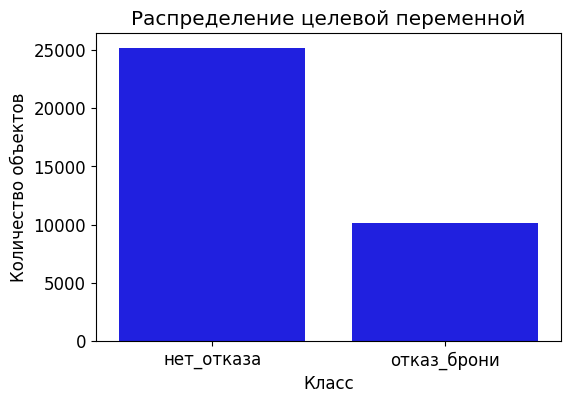

In [7]:
def target_distribution(x):
    value_counts = x.value_counts()
    value_share = x.value_counts(normalize=True)
    print('Количество объектов:')
    print(value_counts)
    print('Доли классов:')
    print(value_share)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=x, color='blue')
    plt.title('Распределение целевой переменной')
    plt.xlabel('Класс')
    plt.ylabel('Количество объектов')
    plt.show()
target_distribution(hotel_bookings['booking_status'])

<h4>Вывод по распределению</h4>
Распределение целевой не равномерно
<ul>
    <li><code>нет_отказа</code> - 0.71 от общей выборки</li>
    <li><code>отказ_брони</code> - 0.28 от общей выборки</li>
</ul>
Слова заказчика подтведились при обучение необходимо использовать методы балансировки
<ul>
    <li>Undersampling случайное уменьшение объёма большего класса</li>
    <li>Oversampling увеличение объёма меньшего класса (SMOTE генерирует новые на основе ближайших соседей в отличие от классического копирования)</li>
    <li>Взвешивание классов данные не изменяются, модель сильнее реагирует на ошибки меньшего классе</li>
</ul>

<h3>Обработка дубликатов</h3>

Для начала рассмотрим явные дубли по отзывам

In [8]:
text_dup = hotel_reviews.duplicated(subset=['review_text']).sum()
print("Дубликаты по review_text:", text_dup)
review_text_counts = hotel_reviews['review_text'].value_counts()
### Порог по количеству дубликатов
at, to = 1, 5 
###
print(review_text_counts[(review_text_counts >= at) & (review_text_counts <= to)])

Дубликаты по review_text: 11024
review_text
Неплохо. спа‑услуги на отлично, но мусор у входа в отель.                                                          5
Неплохо. разнообразное меню в ресторане, но неудобная мебель.                                                      5
Неплохо. удобное расположение, но неудобное расположение.                                                          5
Неплохо. удобные лифты, но мусор у входа в отель.                                                                  5
Неплохо. современные номера, но сломанный кондиционер.                                                             5
                                                                                                                  ..
Неплохо. уютная атмосфера, но медленный интернет. Кондиционер не справлялся, тяжело в номере                       1
Крайне недоволен. отсутствие парковки. больше не буду бронировать через этот сайт                                  1
Неплохо. своевременн

Дубликаты по review_text (44%) не проблема данных, а особенность сгенерированного датасета судя по ручному разных порогов: отзывы сгенерированы из набора шаблонных фраз, поэтому кнекоторые фразы повторяются часто, а длинные редко. Поиск дубликатов здесь неинформативен, удалять строки не нужно.

In [9]:
def duplicates_report(df, id_col=None):
    full_dup = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dup)

    if id_col is not None and id_col in df.columns:
        id_dup = df.duplicated(subset=[id_col]).sum()
        print("Дубликаты по id:", id_dup)
        no_id = df.drop(columns=[id_col])
        no_id_dup = no_id.duplicated().sum()
        print("Дубликаты без id:", no_id_dup)

In [10]:
duplicates_report(hotel_reviews, id_col='booking_id')

Полные дубликаты строк: 0
Дубликаты по id: 3294
Дубликаты без id: 0


Теперь дубликатов нет, дубликаты по id логичны так как пользователь может оставить больше 1 отзыва на одну бронь 

In [11]:
duplicates_report(hotel_bookings, id_col='booking_id')

Полные дубликаты строк: 4608
Дубликаты по id: 4608
Дубликаты без id: 4608


Все дубликаты по id в действительности оуказались дубликатоми в целом следует их удалить 

In [12]:
hotel_bookings = hotel_bookings.drop_duplicates(subset=['booking_id']).reset_index(drop=True)

Теперь рассмотрим неявные дубликаты в категориях таблицы booking

In [13]:
def categorical_analysis(df, cat_cols):
    for col in cat_cols:
        print("Столбец:", col)
        print("Уникальных значений:", df[col].nunique())
        print("Возможные значения:", df[col].unique())
        print()

In [14]:
cat_cols = ['sales_channel', 'meal_plan', 'room_type']

categorical_analysis(hotel_bookings, cat_cols)
for col in cat_cols:
    print("\t", hotel_bookings[col].value_counts())

Столбец: sales_channel
Уникальных значений: 3
Возможные значения: <StringArray>
['корпоративное_бронирование', 'онлайн_бронирование', 'офлайн_бронирование']
Length: 3, dtype: str

Столбец: meal_plan
Уникальных значений: 5
Возможные значения: <StringArray>
['тип_питания_2', 'тип_питания_1', 'не выбран', 'не выбрант', 'тип_питания_3']
Length: 5, dtype: str

Столбец: room_type
Уникальных значений: 7
Возможные значения: <StringArray>
['тип_1', 'тип_4', 'тип_6', 'тип_2', 'тип_5', 'тип_7', 'тип_3']
Length: 7, dtype: str

	 sales_channel
офлайн_бронирование           10447
корпоративное_бронирование    10228
онлайн_бронирование           10058
Name: count, dtype: int64
	 meal_plan
тип_питания_1    23604
не выбран         3868
тип_питания_2     2826
не выбрант         430
тип_питания_3        5
Name: count, dtype: int64
	 room_type
тип_1    23687
тип_4     5243
тип_6      832
тип_2      578
тип_5      242
тип_7      143
тип_3        8
Name: count, dtype: int64


присутствует опечатка в колонке meal_plan - "не выбрант" необходимо заменить эти значения на "не выбран" и снова сделаать проверку на появление новых дубликатов

In [15]:
hotel_bookings['meal_plan'] = hotel_bookings['meal_plan'].replace('не выбрант', 'не выбран')
print(hotel_bookings['meal_plan'].value_counts())

meal_plan
тип_питания_1    23604
не выбран         4298
тип_питания_2     2826
тип_питания_3        5
Name: count, dtype: int64


In [16]:
duplicates_report(hotel_bookings, id_col='booking_id')

Полные дубликаты строк: 0
Дубликаты по id: 0
Дубликаты без id: 0


Новых дубликатов не появилось

<h3>Анализ категориальных признаков</h3>

In [17]:
cat_cols = ['sales_channel', 'meal_plan', 'room_type']

categorical_analysis(hotel_bookings, cat_cols)

Столбец: sales_channel
Уникальных значений: 3
Возможные значения: <StringArray>
['корпоративное_бронирование', 'онлайн_бронирование', 'офлайн_бронирование']
Length: 3, dtype: str

Столбец: meal_plan
Уникальных значений: 4
Возможные значения: <StringArray>
['тип_питания_2', 'тип_питания_1', 'не выбран', 'тип_питания_3']
Length: 4, dtype: str

Столбец: room_type
Уникальных значений: 7
Возможные значения: <StringArray>
['тип_1', 'тип_4', 'тип_6', 'тип_2', 'тип_5', 'тип_7', 'тип_3']
Length: 7, dtype: str



Высокой кардинальности и странных значений нет ни у одного признака, для кодеровки признаков используем OHE  переходим к анализу числовых

<h3>Анализ выбросов и распределления</h3>

In [18]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    low_outliers = data[data < lower_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    print("Первые 5 выбросов ниже нижней границы:", low_outliers.tail(5).values)
    print("5 минимальных значений:", low_outliers.head(5).values)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title(f"Hist: {col}")
    sns.boxplot(x=data, ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

Столбец: booking_value
count     30733.000000
mean      61679.168347
std       42737.289170
min           0.000000
25%       33500.000000
50%       60300.000000
75%       80400.000000
max      417221.200000
Name: booking_value, dtype: float64
Выбросы:
Количество: 866
Процент: 2.82
Границы: -36850.0 150750.0
Первые 5 выбросов выше верхней границы: [150766.1 150807.9 150893.7 151181.4 151300. ]
5 максимальных значений: [386732.  391050.3 409984.4 413673.6 417221.2]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


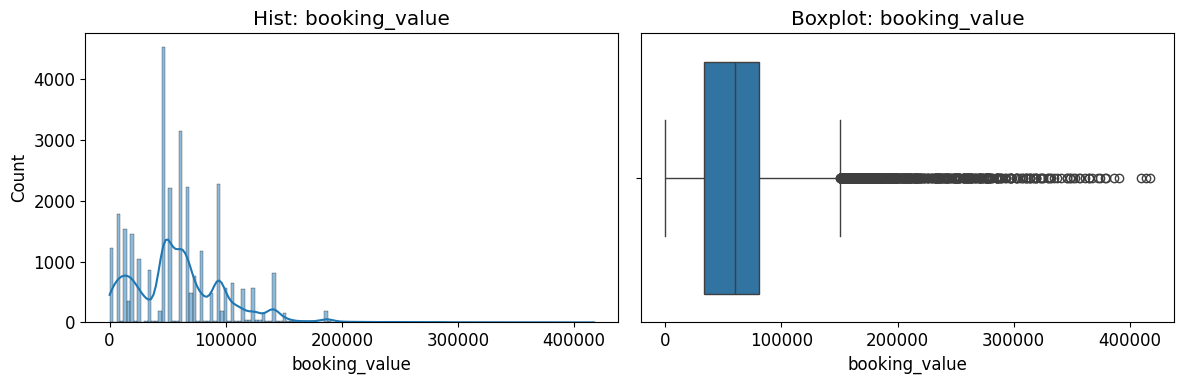


Столбец: days_until_checkin
count    30733.000000
mean       100.598770
std         71.933406
min          2.000000
25%         45.000000
50%         90.000000
75%        144.000000
max        300.000000
Name: days_until_checkin, dtype: float64
Выбросы:
Количество: 340
Процент: 1.11
Границы: -103.5 292.5
Первые 5 выбросов выше верхней границы: [300 300 300 300 300]
5 максимальных значений: [300 300 300 300 300]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


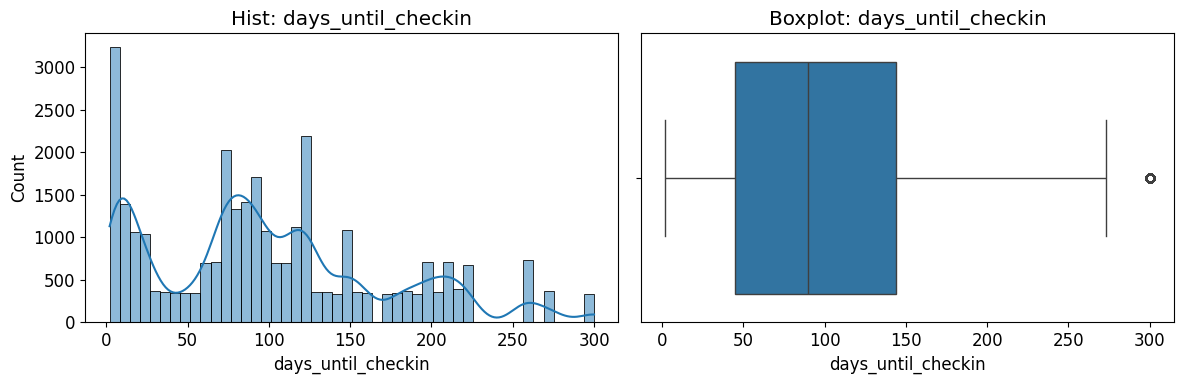

In [19]:
num_cols = ['booking_value', 'days_until_checkin']

for col in num_cols:
    print("Столбец:", col)
    data_review(hotel_bookings, col)
    print()

adult_count
1      11490
2      11272
3       5820
100      884
200      872
300      395
Name: count, dtype: int64 



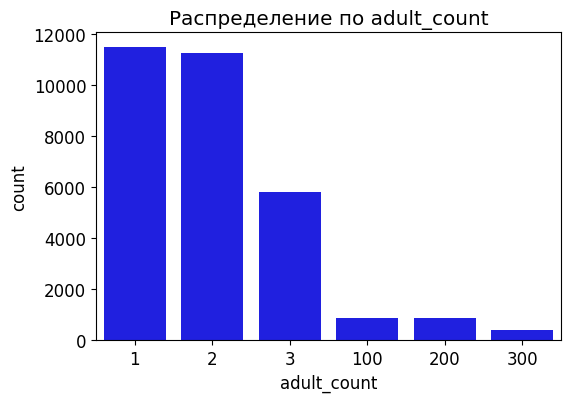

child_count
0    21496
1     7512
2     1725
Name: count, dtype: int64 



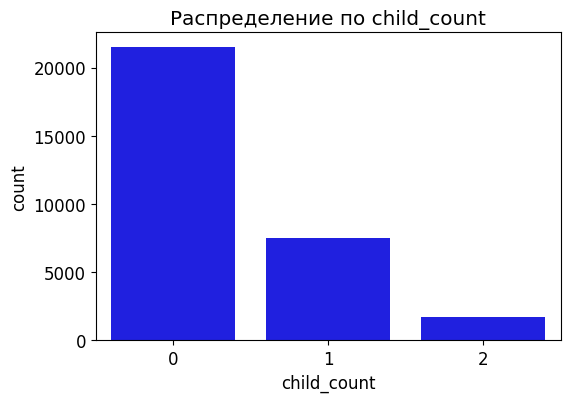

previous_cancellations
0    21874
1     7117
2     1420
3      268
4       50
5        4
Name: count, dtype: int64 



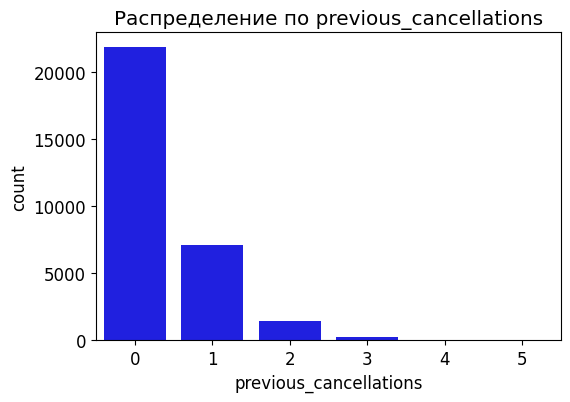

previous_no_shows
0    13408
1    11180
2     4288
3     1435
4      386
5       36
Name: count, dtype: int64 



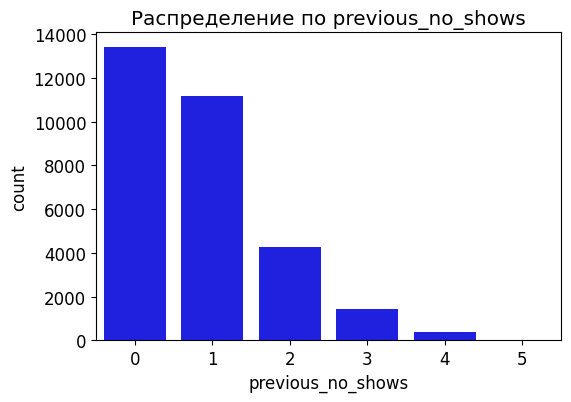

weekday_nights
5     7009
10    3972
8     2992
6     2941
7     2913
2     1994
1     1977
3     1907
9      979
4      964
15     937
11     735
12     708
13     705
Name: count, dtype: int64 



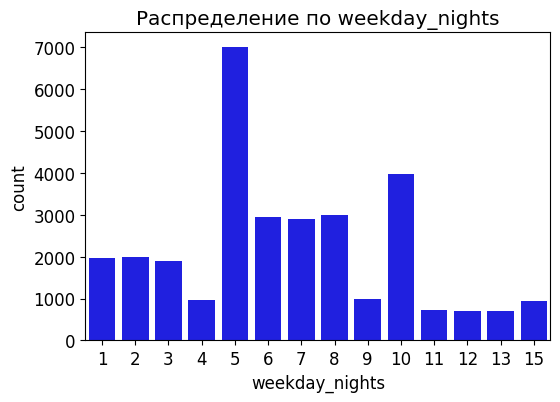

weekend_nights
2    16781
0     7792
4     5223
6      937
Name: count, dtype: int64 



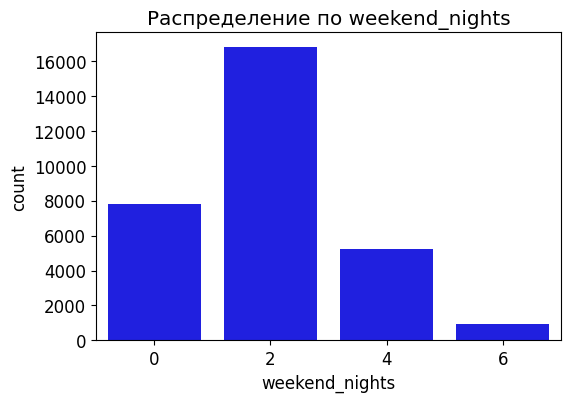

customer_special_requests
0    16716
1     9657
2     3742
3      547
4       64
5        7
Name: count, dtype: int64 



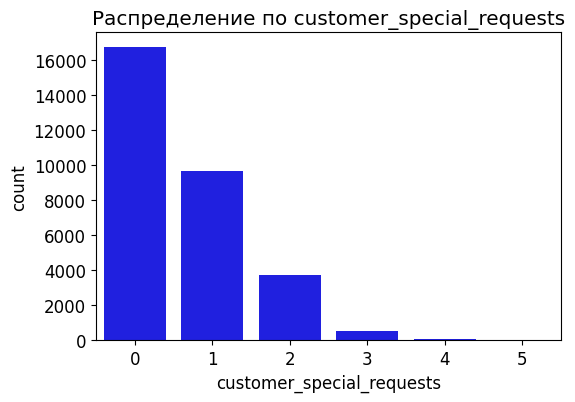

In [20]:
low_cardinal_nums = ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'weekday_nights', 'weekend_nights', 'customer_special_requests']
for col in low_cardinal_nums:
    print(hotel_bookings[col].value_counts(), "\n")
    plt.figure(figsize = (6, 4))
    sns.countplot(x=hotel_bookings[col], color='blue')
    plt.title(f"Распределение по {col}")
    plt.show()

Обнаружены аномальные значения в adult_count, удостоверимся что это ошибки сравнив средние цены бронирования  

In [21]:
display(hotel_bookings[hotel_bookings["adult_count"] > 99]["booking_value"].mean())
display(hotel_bookings[hotel_bookings["adult_count"] < 99]["booking_value"].mean())

np.float64(60303.201487680155)

np.float64(61782.71969771185)

Ошибка подтверждена средние цены отличаются незначиттельно значит это ошибка данных исправляем

In [22]:
hotel_bookings['adult_count'] = hotel_bookings['adult_count'].replace(100, 1)
hotel_bookings['adult_count'] = hotel_bookings['adult_count'].replace(200, 2)
hotel_bookings['adult_count'] = hotel_bookings['adult_count'].replace(300, 3)

print(hotel_bookings['adult_count'].value_counts())
duplicates_report(hotel_bookings, id_col='booking_id')

adult_count
1    12374
2    12144
3     6215
Name: count, dtype: int64
Полные дубликаты строк: 0
Дубликаты по id: 0
Дубликаты без id: 0


Ошибка исправлена новых дубликатов не появилось

Проверим нулевые значения столбца <code>booking_value</code> не являются они аномальными

In [23]:
zero_value = hotel_bookings[hotel_bookings['booking_value'] == 0]

print('Количество:', len(zero_value))
print('Доля :', len(zero_value) / len(hotel_bookings) * 100)

display(zero_value.head())
print("Среднее по 10 минимальным booking_value кроме значения 0", hotel_bookings[hotel_bookings['booking_value'] > 0]['booking_value'].sort_values().head(10).mean())

Количество: 1229
Доля : 3.9989587739563333


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
11,INN00011,2021-11-04,онлайн_бронирование,2,0,True,0,1,нет_отказа,0.0,3,1,0,тип_питания_1,False,тип_1,1
105,INN00105,2019-07-19,офлайн_бронирование,2,0,False,0,0,отказ_брони,0.0,67,6,2,тип_питания_1,False,тип_1,1
133,INN00133,2021-12-13,корпоративное_бронирование,2,0,True,0,1,нет_отказа,0.0,77,6,2,тип_питания_1,False,тип_1,3
143,INN00143,2020-05-15,офлайн_бронирование,3,0,False,0,0,отказ_брони,0.0,157,1,0,тип_питания_1,True,тип_1,0
145,INN00145,2019-03-06,офлайн_бронирование,1,0,False,0,0,нет_отказа,0.0,7,3,0,тип_питания_1,False,тип_1,2


Среднее по 10 минимальным booking_value кроме значения 0 6700.0


1229 строк с booking_value = 0. Закономерности по sales_channel, room_type, booking_status и другим признакам нет. При этом между 0 и следующими ценами есть разрыв без промежуточных значений Проверим единственный ли это разрыв

In [24]:
value_counts_ = hotel_bookings['booking_value'].value_counts()

print('Топ-10 частовстречаемых значений booking_value:')
print(value_counts_.head(10))

print('Всего уникальных значений:', hotel_bookings['booking_value'].nunique())
print('Встречаются больше 1 раза:', (value_counts_ > 1).sum())

Топ-10 частовстречаемых значений booking_value:
booking_value
46900.0    4512
93800.0    2247
67000.0    2230
53600.0    2190
60300.0    2167
13400.0    1493
6700.0     1460
20100.0    1429
0.0        1229
62300.0     966
Name: count, dtype: int64
Всего уникальных значений: 1766
Встречаются больше 1 раза: 33


<p>
booking_value имеет разрывы в значениях 46900, 93800, 67000, 53600, 60300, 13400, 6700  кратны 6700, это причина сгенерированных данных. booking_value = 0 ещё одно кратное значение в этой структуре
</p>
<p>
строки с 0 значением удаляются
</p>

In [25]:
hotel_bookings = hotel_bookings[hotel_bookings['booking_value'] > 0].reset_index(drop=True)

<h4>Вывод по распределению числовых признаков</h4>
<ul>
    <li><code>child_count</code>, <code>previous_cancellations</code>, <code>customer_special_requests</code> убывающее распределение, аномалий не выявлено</li>
    <li><code>weekend_nights</code> только чётные значения (0,2,4,6) (выходные всегда идут парой)</li>
    <li><code>weekday_nights</code> от 1 до 15, распределение неравномерное, явных аномалий нет</li>
    <li><code>adult_count</code> обнаружены аномальные значения 100, 200 и 300 , исправлены на 1, 2 и 3</li>
    <li><code>booking_value</code> минимум 0руб, среднее 61700руб, выбросы сверху (2.82%, максимум - 417221 ₽) плавный правый хвост распределения данные соответствуют реальным высоким значениям - не удаляем</li>
    <li><code>days_until_checkin</code> диапазон 2–300 дней, выбросы (1.11%) все выбросы одинаковы(300) аномалий нет </li>
</ul>

<h3>Корреляции</h3>

In [26]:
def phik_corr_matrix(df, interval_cols=None, drop_cols=None):
    data = df.copy()
    
    if drop_cols:
        data = data.drop(columns=drop_cols, errors='ignore')

    plt.figure(figsize = (14, 12))
    corr = data.phik_matrix(interval_cols=interval_cols)
    sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
    plt.show()
    
    return corr

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable booking_date is large: 2440. Are you sure this is not an interval variable? Analysis for pairs of variables including booking_date can be slow.
  warnings.warn(


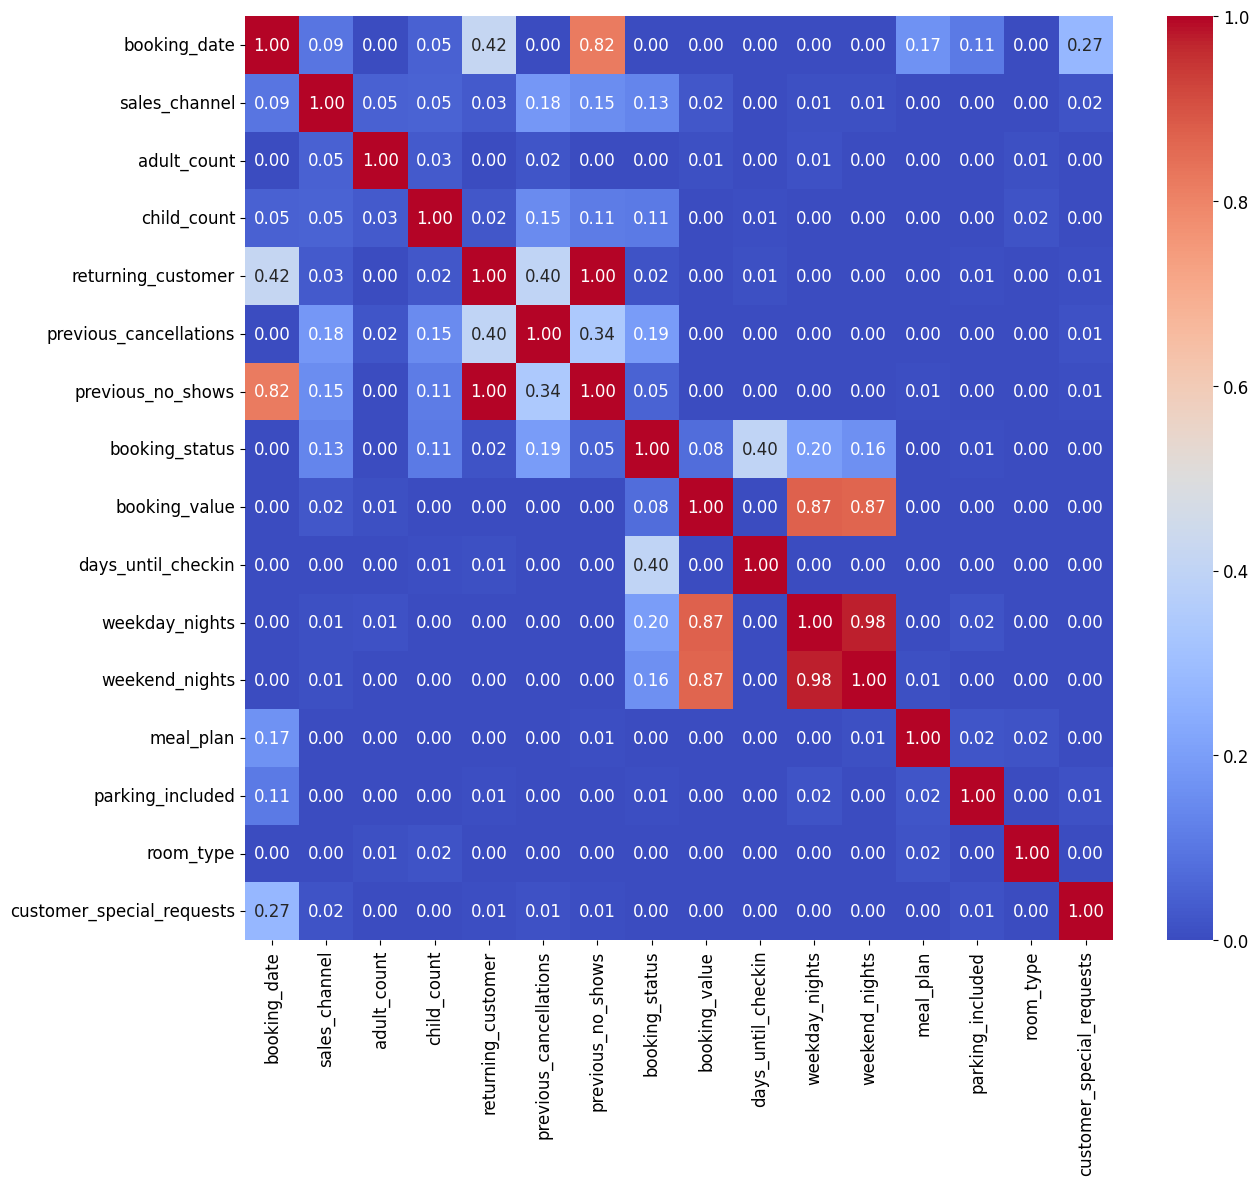

In [27]:
drop_cols = ['booking_id']
interval_cols = ['booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights']

corr = phik_corr_matrix(hotel_bookings, interval_cols=interval_cols, drop_cols=drop_cols)

<h4>Вывод по корреляционному анализу</h4>
<ul>
    <li><code>booking_status</code> сильнее всего связана с <code>days_until_checkin</code>, <code>weekday_nights</code>, <code>previous_cancellations</code>, <code>weekend_nights</code>, <code>sales_channel</code>, <code>booking_value</code>, <code>child_count</code> - важные признаки для модели</li>
    <li>Полная корреляция <code>returning_customer</code> и <code>previous_no_shows</code> признаки дублируют друг друга </li>
    <li><code>booking_date</code> и <code>previous_no_shows</code> высокая корреляция (0.81)</li>
    <li>Сильная мультиколлинеарность между <code>weekday_nights</code>, <code>weekend_nights</code> и <code>booking_value</code> (0.86–0.98) стоимость брони прямо зависит от количества ночей, что логично</li>
    <li><code>previous_cancellations</code> и <code>returning_customer</code> умеренно связаны 0.40 </li>
    <li>Признаки <code>adult_count</code>, <code>room_type</code>, <code>meal_plan</code>, <code>parking_included</code> слабая связь с целевой переменной</li>
</ul>

<h2>Этап 3 Объединение таблиц: объединим таблицы с учетом времянной структуры, создадим новые признаки на основе имеющихся</h2>

<h3>Создание единой таблицы</h3>

In [28]:
with_customers = hotel_bookings.merge(hotel_reviews[['booking_id', 'customer_id']], on='booking_id', how='left')
with_customers = with_customers.drop_duplicates().reset_index(drop=True)

merged = with_customers.merge(hotel_reviews, on='customer_id', how='left', suffixes=('', '_'))
early_only = merged[merged['review_date'] < merged['booking_date']]
early_only_sorted = early_only.sort_values('review_date')
last_reviews = early_only_sorted.groupby('booking_id').tail(1)

df = hotel_bookings.merge(last_reviews[['booking_id', 'customer_id', 'review_date', 'stay_rating', 'review_text']], on='booking_id', how='left')

print('Размер hotel_bookings:', hotel_bookings.shape[0])
print('Размер финальной таблицы:', df.shape)
print('Доля строк без отзыва:', df['review_date'].isna().mean() * 100)

display(df.head())

Размер hotel_bookings: 29504
Размер финальной таблицы: (29504, 21)
Доля строк без отзыва: 72.8138557483731


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,...,1,0,тип_питания_2,False,тип_1,0,NaN,NaN,NaN,NaN
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,...,5,2,тип_питания_2,False,тип_1,1,C0001,2020-08-21,3.0,"Неплохо. тихо и спокойно, но отсутствие фена в..."
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,...,5,2,тип_питания_1,False,тип_1,0,C0001,2021-10-15,3.0,"Неплохо. красивое оформление территории, но не..."
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,...,6,2,тип_питания_1,False,тип_1,0,NaN,NaN,NaN,NaN
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,...,5,2,тип_питания_1,False,тип_1,1,NaN,NaN,NaN,NaN


<p>
для каждой брони найден отзыв с ближайшей предыдущей датой review_date, оставленный тем же клиентом 
</p>
<p>
Итоговый размер таблицы после объединения совпадает с hotel_bookings 30733 строки. Доля броней без предыдущего отзыва 72.9% такая большая доля связана с правилом отбора отзывов, требуется чтобы это была не первая бронь пользователя(так как для отзыва нужен booking_id, а отзыв должен быть до брони) и чтобы после 1 брони был оставлен отзыв
</p>

Теперь преобразуем текст удалив лишние симоволы и слова, преобразование через TD-IDF сделаем после разбиения на выборки

In [29]:
russian_stopwords = set(stopwords.words("russian"))

def remove_stopwords(text_tokens):
    filtered_sentence = [word for word in text_tokens if word not in russian_stopwords]
    return " ".join(filtered_sentence)

df['review_text'] = df['review_text'].fillna('')

df['review_text_clean'] = df['review_text'].str.replace(r'[^\w\s]|[\s]+', ' ', regex=True)
df['review_text_clean'] = df['review_text_clean'].str.strip()
df['review_text_clean'] = df['review_text_clean'].str.lower()
df['tokens'] = df['review_text_clean'].str.split()
df['review_text_clean'] = df['tokens'].apply(remove_stopwords)
df = df.drop(columns=['tokens'])

<h3>Создадим новые признаки на основе имеющихся </h3>
<ul>
    <li><code>booking_value_per_person</code> - цена бронирования на человека</li>
    <li><code>booking_value_per_night</code> - цена бронирования за одну ночь</li>
    <li><code>returning_guest</code> - повторный клиент, который реально жил в отеле (без отмен и без неявок)</li>
    <li><code>rating_per_value</code> - оценка проживания с учётом цены за ночь</li>
    <li><code>long_planned</code> - признак долгосрочно спланированного отпуска, а не короткого визита</li>
    <li><code>cancellation_history</code> - доля отмен</li>
    <li><code>checkin_month</code> - месяц заезда для выявления сезонности во время заезда</li>
</ul>

In [30]:
persons_count = df['adult_count'] + df['child_count']
df['booking_value_per_person'] = df['booking_value'] / persons_count.mask(persons_count == 0)

nights = df['weekday_nights'] + df['weekend_nights']
df['booking_value_per_night'] = df['booking_value'] / nights.mask(nights == 0)

df['returning_guest'] = ((df['returning_customer'] == 1) & (df['previous_cancellations'] == 0))
df['rating_per_value'] = df['stay_rating'] / df['booking_value_per_night'].mask(df['booking_value_per_night'] == 0)
df['long_planned'] = ((df['days_until_checkin'] > 100) & (nights > 5)).astype(int)


df['booking_date'] = pd.to_datetime(df['booking_date'])
df['checkin_date'] = df['booking_date'] + pd.to_timedelta(df['days_until_checkin'], unit='D')
df['checkin_month'] = df['checkin_date'].dt.month

df['cancellation_history'] = (df['previous_cancellations'] / (df['previous_cancellations'] + df['previous_no_shows'] + 1))

<h3>Анализ итоговой таблицы</h3>

In [31]:
def missing_report(df):
    total = len(df)
    for col in df.columns:
        print(col)
        print("\t", "пропусков:", df[col].isna().sum())
        print("\t", f"доля: {round(df[col].isna().sum() / total * 100, 2)}%")
    df_clean = df.dropna()
    print("Без удаления пропусков строк:", len(df))
    print("После удаления:", len(df_clean))
    print("Потеря:", len(df) - len(df_clean))
    print("Доля потерь:", (len(df) - len(df_clean)) / len(df))

missing_report(df)

booking_id
	 пропусков: 0
	 доля: 0.0%
booking_date
	 пропусков: 0
	 доля: 0.0%
sales_channel
	 пропусков: 0
	 доля: 0.0%
adult_count
	 пропусков: 0
	 доля: 0.0%
child_count
	 пропусков: 0
	 доля: 0.0%
returning_customer
	 пропусков: 0
	 доля: 0.0%
previous_cancellations
	 пропусков: 0
	 доля: 0.0%
previous_no_shows
	 пропусков: 0
	 доля: 0.0%
booking_status
	 пропусков: 0
	 доля: 0.0%
booking_value
	 пропусков: 0
	 доля: 0.0%
days_until_checkin
	 пропусков: 0
	 доля: 0.0%
weekday_nights
	 пропусков: 0
	 доля: 0.0%
weekend_nights
	 пропусков: 0
	 доля: 0.0%
meal_plan
	 пропусков: 0
	 доля: 0.0%
parking_included
	 пропусков: 0
	 доля: 0.0%
room_type
	 пропусков: 0
	 доля: 0.0%
customer_special_requests
	 пропусков: 0
	 доля: 0.0%
customer_id
	 пропусков: 21483
	 доля: 72.81%
review_date
	 пропусков: 21483
	 доля: 72.81%
stay_rating
	 пропусков: 21483
	 доля: 72.81%
review_text
	 пропусков: 0
	 доля: 0.0%
review_text_clean
	 пропусков: 0
	 доля: 0.0%
booking_value_per_person
	 пропусков:

<h4>Вывод по пропускам в итоговом df</h4>
Пропуски в признаках, связанных с отзывами клиента одинаковая доля пропусков (72.89%), чуть больше в <code>rating_per_value</code> из за наличия рейтинга у строк с <code>booking_value</code> равным 0, заполнение медианой или модой для этиъ строк не подходит из - за количества пропусков данные станут слишком шумными замени всем пропуски на 0 или 'нет отзыва' так же дополнительно создадим для модели признак флаг был ли отзыв

In [32]:
df['has_previous_review'] = df['stay_rating'].notna().astype(int)

df['stay_rating'] = df['stay_rating'].fillna(0)
df['rating_per_value'] = df['rating_per_value'].fillna(0)
df['customer_id'] = df['customer_id'].fillna('нет_отзыва')
df['review_date'] = df['review_date'].fillna('нет_отзыва')

print(df.isna().sum())

booking_id                   0
booking_date                 0
sales_channel                0
adult_count                  0
child_count                  0
returning_customer           0
previous_cancellations       0
previous_no_shows            0
booking_status               0
booking_value                0
days_until_checkin           0
weekday_nights               0
weekend_nights               0
meal_plan                    0
parking_included             0
room_type                    0
customer_special_requests    0
customer_id                  0
review_date                  0
stay_rating                  0
review_text                  0
review_text_clean            0
booking_value_per_person     0
booking_value_per_night      0
returning_guest              0
rating_per_value             0
long_planned                 0
checkin_date                 0
checkin_month                0
cancellation_history         0
has_previous_review          0
dtype: int64


Пропусков больше нет 

In [33]:
duplicates_report(df, id_col='booking_id')

Полные дубликаты строк: 0
Дубликаты по id: 0
Дубликаты без id: 0


Дубликатов нет

Столбец: booking_value
count     29504.000000
mean      64248.436849
std       41683.137007
min        6700.000000
25%       46900.000000
50%       60300.000000
75%       89000.000000
max      417221.200000
Name: booking_value, dtype: float64
Выбросы:
Количество: 732
Процент: 2.48
Границы: -16250.0 152150.0
Первые 5 выбросов выше верхней границы: [152273.  152402.8 152782.6 153024.  153046.4]
5 максимальных значений: [386732.  391050.3 409984.4 413673.6 417221.2]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


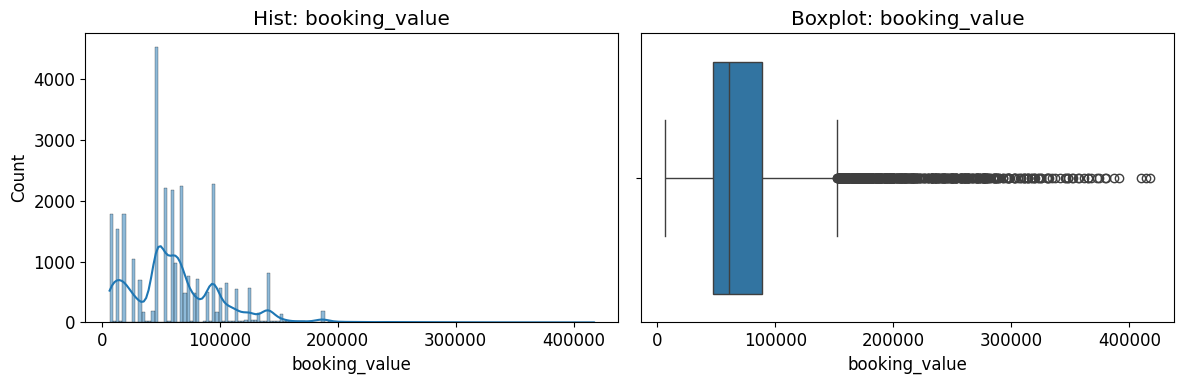

Столбец: days_until_checkin
count    29504.000000
mean       100.541994
std         71.926833
min          2.000000
25%         45.000000
50%         90.000000
75%        144.000000
max        300.000000
Name: days_until_checkin, dtype: float64
Выбросы:
Количество: 327
Процент: 1.11
Границы: -103.5 292.5
Первые 5 выбросов выше верхней границы: [300 300 300 300 300]
5 максимальных значений: [300 300 300 300 300]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


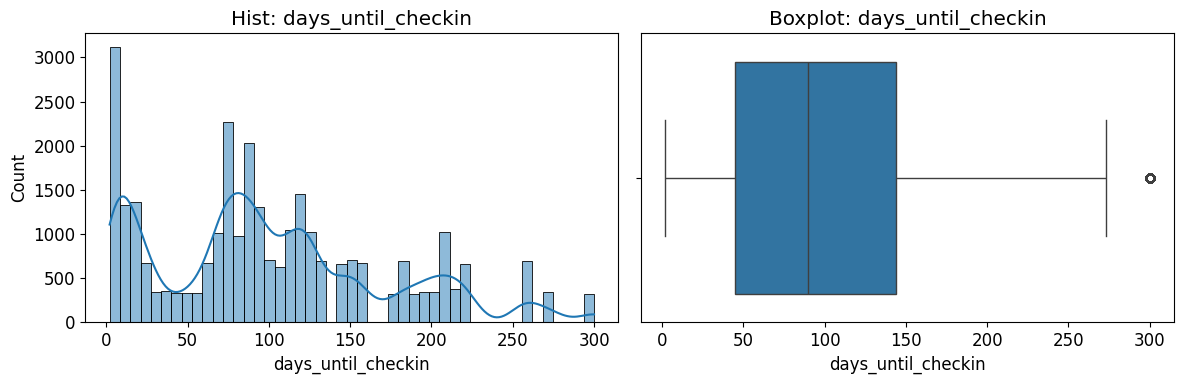

Столбец: booking_value_per_person
count     29504.000000
mean      37008.059779
std       32169.050186
min        1340.000000
25%       15633.333333
50%       26800.000000
75%       46900.000000
max      417221.200000
Name: booking_value_per_person, dtype: float64
Выбросы:
Количество: 1440
Процент: 4.88
Границы: -31266.67 93800.0
Первые 5 выбросов выше верхней границы: [93954.4  93976.2  94076.95 94378.45 94605.5 ]
5 максимальных значений: [352509.6 372672.9 379837.9 409984.4 417221.2]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


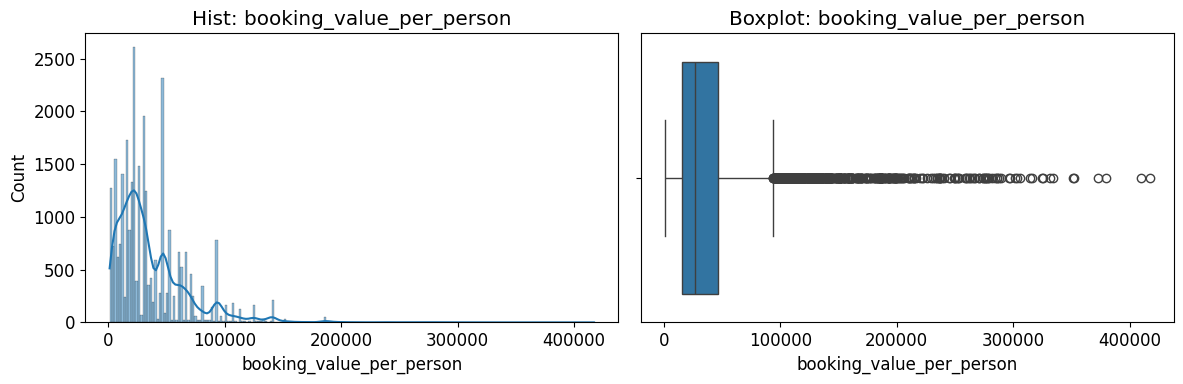

Столбец: booking_value_per_night
count    29504.000000
mean      7564.290504
std       2167.888292
min       6700.000000
25%       6700.000000
50%       6700.000000
75%       6700.000000
max      19995.350000
Name: booking_value_per_night, dtype: float64
Выбросы:
Количество: 6695
Процент: 22.69
Границы: 6700.0 6700.0
Первые 5 выбросов выше верхней границы: [8900. 8900. 8900. 8900. 8900.]
5 максимальных значений: [19985.4        19985.4        19992.08888889 19993.2
 19995.35      ]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


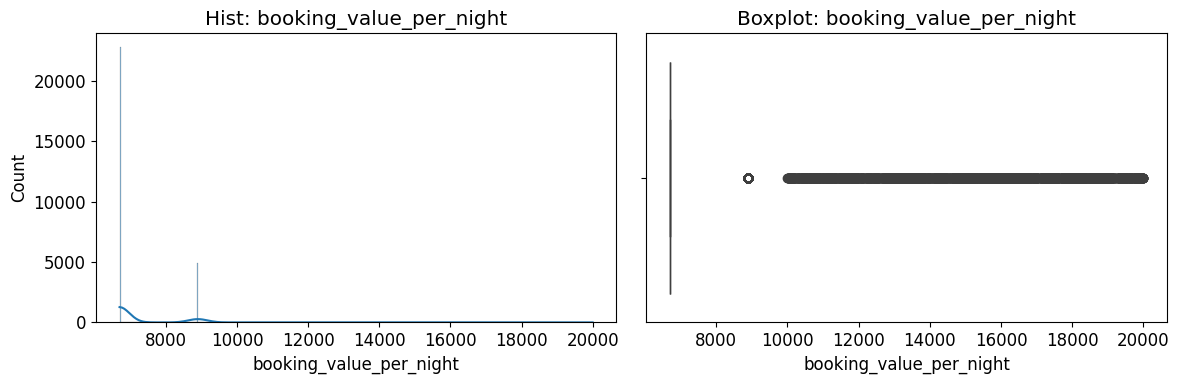

Столбец: rating_per_value
count    29504.000000
mean         0.000128
std          0.000217
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000337
max          0.000746
Name: rating_per_value, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -0.0 0.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


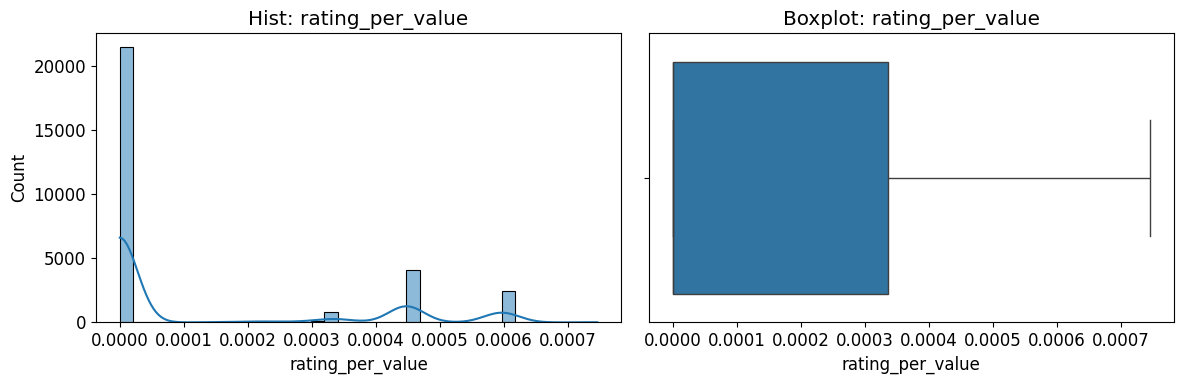

Столбец: cancellation_history
count    29504.000000
mean         0.108494
std          0.182251
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          0.800000
Name: cancellation_history, dtype: float64
Выбросы:
Количество: 397
Процент: 1.35
Границы: -0.38 0.62
Первые 5 выбросов выше верхней границы: [0.66666667 0.66666667 0.66666667 0.66666667 0.66666667]
5 максимальных значений: [0.8 0.8 0.8 0.8 0.8]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


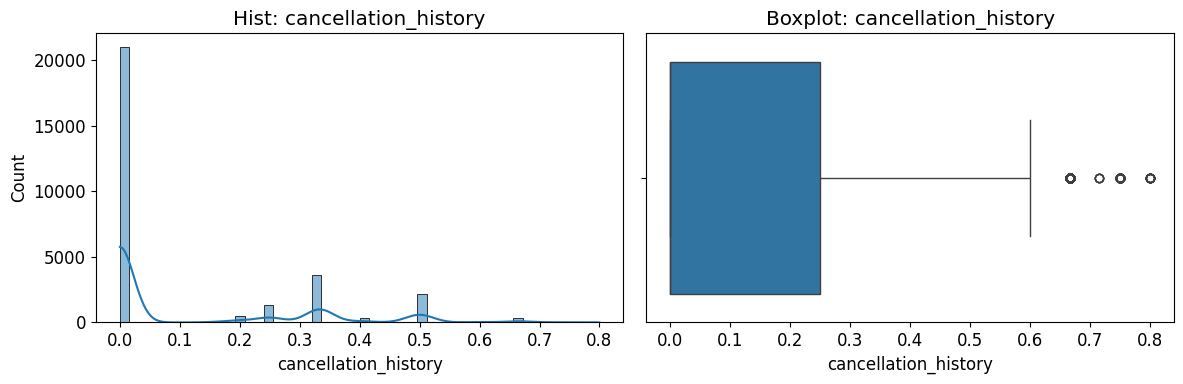

In [34]:
num_cols = ['booking_value', 'days_until_checkin', 'booking_value_per_person', 'booking_value_per_night',
            'rating_per_value', 'cancellation_history']

for col in num_cols:
    print("Столбец:", col)
    data_review(df, col)

<h4>Вывод по числовым признакам итогового df</h4>
<ul>
    <li><code>booking_value</code>, <code>days_until_checkin</code> - распределения не изменились после объединения таблиц</li>
    <li><code>booking_value_per_night</code> IQR показывает 25.78% выбросов: из-за структуры цен большинство значений равны ровно 6700, и любое отклонение попадает в выбросы. Реальной аномалии нет</li
</ul>

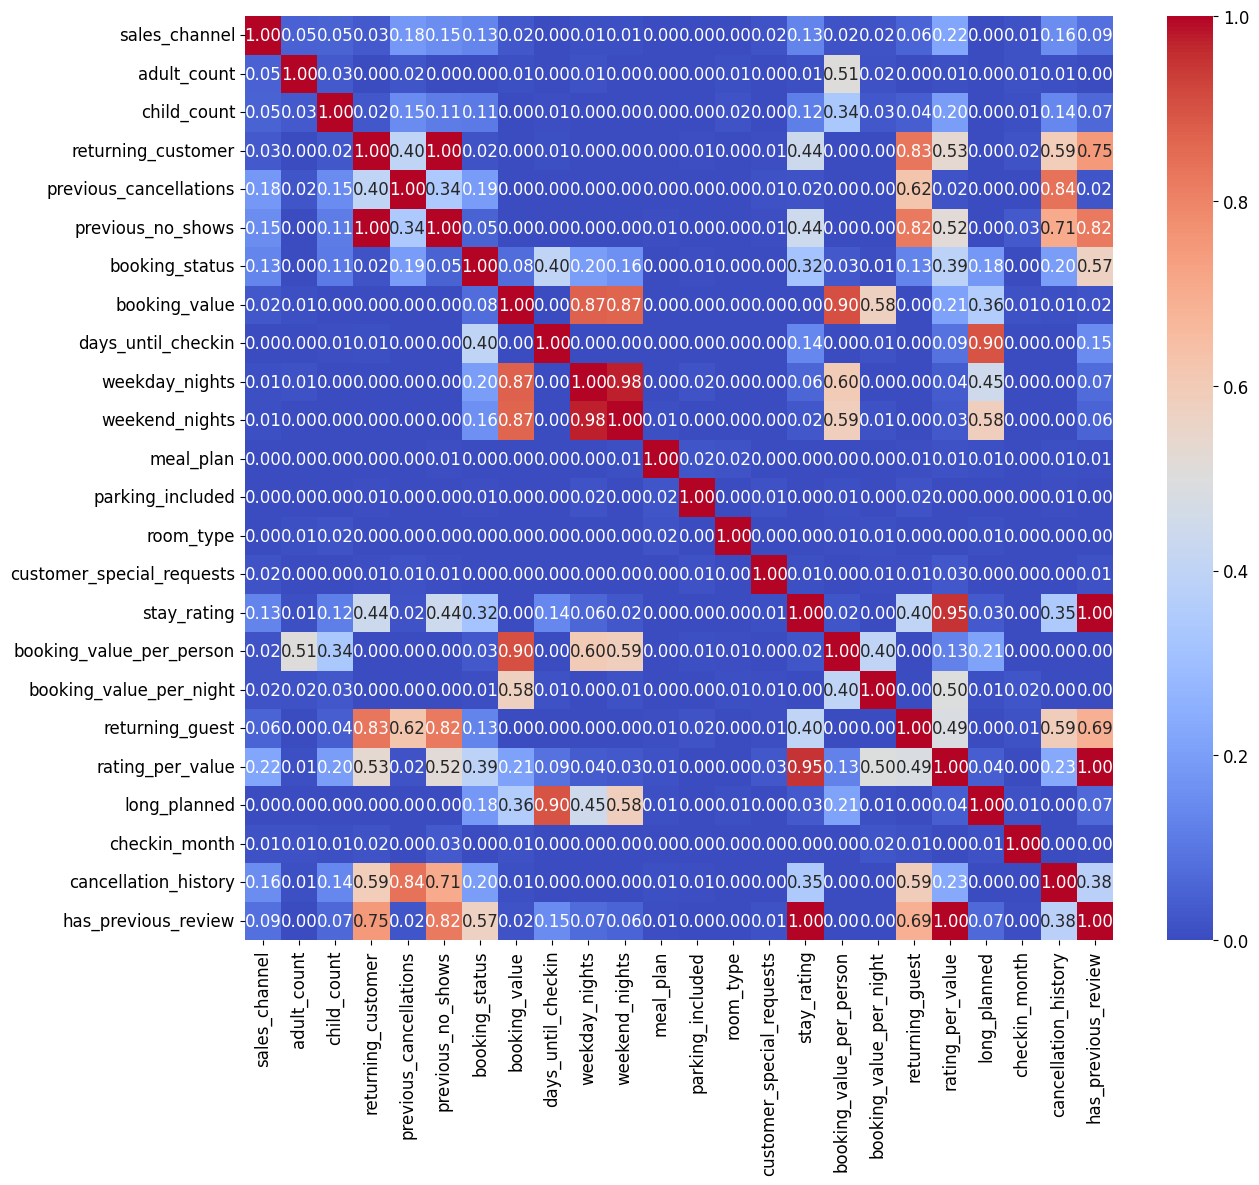

In [35]:
drop_cols = ['booking_id', 'customer_id', 'review_text', 'review_text_clean',
             'checkin_date', 'booking_date', 'review_date']

interval_cols = ['booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights', 'booking_value_per_person', 'booking_value_per_night',
                 'rating_per_value', 'cancellation_history']

corr = phik_corr_matrix(df, interval_cols=interval_cols, drop_cols=drop_cols)

<h4>Вывод по корреляционному анализу</h4>
<ul>
    <li>Новые признаки показываю сильную связь со своими  исходными признаками, так как они являются из результатом, а не независимыми источниками информации:
        <ul>
            <li><code>cancellation_history</code> <code>previous_cancellations</code> (0.84), <code>previous_no_shows</code></li>
            <li><code>long_planned</code> <code>days_until_checkin</code> </li>
            <li><code>booking_value_per_person</code> <code>booking_value</code></li>
            <li><code>rating_per_value</code> <code>stay_rating</code></li>
        </ul>
    </li>
    <li><code>returning_guest</code> сильно коррелирует с <code>returning_customer</code> и <code>cancellation_history</code> так как признак строится на их основе</li>
</ul>

<h2>Этап 4 Обучение базовых моделей: Разделим данные на выборки: обучающую (60% данных) калибровочную (20% данных) тестовую (20% данных). Выберим и обучим модели из списка: Random Forest, CatBoost, LightGBM, XGBoost, LogReg, KNN. Проведём кросс-валидацию</h2>

<h3>Разделяем данные на train val test (60/20/20) выделяем целевую переменную</h3>

In [36]:
def split_data(df, target, drop_cols=None, test_size=0.2, random_state=42):
    if drop_cols is None:
        drop_cols = []
    X = df.drop(columns=[target] + drop_cols)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    return X_train, X_test, y_train, y_test

In [37]:
df['target'] = (df['booking_status'] == 'отказ_брони').astype(int)
df = df.sort_values('booking_date').reset_index(drop=True)

drop_cols = ['booking_id', 'customer_id', 'booking_date', 'review_date', 'checkin_date', 'review_text', 'booking_status', 'previous_no_shows']

X_train, X_temp, y_train, y_temp = split_data(df, target='target', drop_cols=drop_cols, test_size=0.4, random_state=RANDOM_STATE)
X_temp['target'] = y_temp
X_cal, X_test, y_cal, y_test = split_data(X_temp, target='target', drop_cols=[], test_size=0.5, random_state=RANDOM_STATE)


X_train, X_temp, y_train, y_temp = split_data(df, target='target', drop_cols=drop_cols, test_size=0.4, random_state=RANDOM_STATE)
X_temp['target'] = y_temp
X_cal, X_test, y_cal, y_test = split_data(X_temp, target='target', drop_cols=[], test_size=0.5, random_state=RANDOM_STATE)

In [38]:
print("Размер обучающей выборки:", X_train.shape)
print("Размер калибровочной выборки:", X_cal.shape)
print("Размер тестовой выборки:", X_test.shape)

print("\nРаспределение target в train:")
print(y_train.value_counts(normalize=True))

print("\nРаспределение target в cal:")
print(y_cal.value_counts(normalize=True))

print("\nРаспределение target в test:")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки: (17702, 23)
Размер калибровочной выборки: (5901, 23)
Размер тестовой выборки: (5901, 23)

Распределение target в train:
target
0    0.704045
1    0.295955
Name: proportion, dtype: float64

Распределение target в cal:
target
0    0.704626
1    0.295374
Name: proportion, dtype: float64

Распределение target в test:
target
0    0.744111
1    0.255889
Name: proportion, dtype: float64


<h3>Сделаем пайплайны отдельно для моделей без встроенного кодеровщика и с ним. Создадим вспомогательную функцую to_category ччтобы явно всем стобцам присвоить тип category для моделей бустинга</h3>

In [39]:
def calculate_ir(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    ir_after = (tp * PerRebooking) + (tn * AvgRev) - (fp * CostFP) - (fn * LostRev)
    return ir_after

cat_cols = ['sales_channel', 'meal_plan', 'room_type']

num_cols = ['adult_count', 'child_count', 'returning_customer', 'previous_cancellations', 'booking_value', 'days_until_checkin', 
            'weekday_nights', 'weekend_nights', 'customer_special_requests', 'booking_value_per_person', 'booking_value_per_night', 'returning_guest', 
            'long_planned', 'cancellation_history', 'stay_rating', 'rating_per_value', 'has_previous_review', 'parking_included', 'checkin_month']


preprocessor_ohe = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
                                                   ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
                                                   ('text', TfidfVectorizer(min_df=5), 'review_text_clean'),])


pipelines = {'LogisticRegression': Pipeline([('preprocessor', preprocessor_ohe),
                                             ('model', LogisticRegression(random_state=RANDOM_STATE))]),
             'KNN': Pipeline([('preprocessor', preprocessor_ohe),
                              ('model', KNeighborsClassifier())]),
             'RandomForest': Pipeline([('preprocessor', preprocessor_ohe),
                                       ('model', RandomForestClassifier(random_state=RANDOM_STATE))])}

scoring = {'roc_auc': 'roc_auc',
           'average_precision': 'average_precision',
           'accuracy': 'accuracy',
           'precision': 'precision',
           'recall': 'recall',
           'f1': 'f1',
           'ir': make_scorer(calculate_ir, greater_is_better=True)}
scoring_boosting = {'roc_auc': roc_auc_score,
                    'average_precision': average_precision_score,
                    'accuracy': accuracy_score,
                    'precision': precision_score,
                    'recall': recall_score,
                    'f1': f1_score,
                    'ir': calculate_ir,}

cv = TimeSeriesSplit(n_splits=3, test_size=2000)

<h3> Создадим функцию для запуска можелей без пайплайна с пересчетоом векторизации для каждого фолда и с преобразованием к типу category</h3>

In [40]:
def evaluate_model_boosting(model, model_name, X, y, cv, cat_cols, text_col='review_text_clean', scoring=None, fit_params=None):
    if fit_params is None:
        fit_params = {}

    start = time.time()
    scores = {name: [] for name in scoring}
    for col in cat_cols:
        X[col] = X[col].astype('category')
    
    for train_idx, val_idx in cv.split(X):
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        tfidf = TfidfVectorizer()
        tfidf.fit(X_train[text_col])
        tfidf_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]

        X_train_tfidf = pd.DataFrame(tfidf.transform(X_train[text_col]).toarray(), columns=tfidf_cols, index=X_train.index)
        X_val_tfidf = pd.DataFrame(tfidf.transform(X_val[text_col]).toarray(), columns=tfidf_cols, index=X_val.index)

        X_train = pd.concat([X_train.drop(columns=[text_col]), X_train_tfidf], axis=1)
        X_val = pd.concat([X_val.drop(columns=[text_col]), X_val_tfidf], axis=1)

        cur_model = clone(model)
        cur_model.fit(X_train, y_train, **fit_params)

        y_pred = cur_model.predict(X_val)
        y_proba = cur_model.predict_proba(X_val)[:, 1]

        for name, scorer in scoring.items():
            if name in ('roc_auc', 'average_precision'):
                scores[name].append(scorer(y_val, y_proba))
            else:
                scores[name].append(scorer(y_val, y_pred))

    duration = time.time() - start
    metrics = {'Model': model_name, 'Duration': round(duration, 2)}
    for name, vals in scores.items():
        metrics[name] = np.mean(vals)
        metrics[f'{name}_std'] = np.std(vals)

    return metrics

<h3>Объявим метрики и функцию для запуска моделей которая возвращает модель и метрики</h3>

In [41]:
def evaluate_model(model, model_name, X, y, cv=cv, scoring=scoring, fit_params={}):
    start = time.time()
    cv_results = cross_validate(estimator=model, X=X, y=y, cv=cv, scoring=scoring, n_jobs=-1, params=fit_params)
    duration = time.time() - start
    metrics = {'Model': model_name, 'Duration': round(duration, 2)}
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        metrics[metric] = scores.mean()
        metrics[f'{metric}_std'] = scores.std()
    model.fit(X, y, **fit_params)
    return model, metrics

In [42]:
metrics_cb = evaluate_model_boosting(CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, allow_writing_files=False),
                                     'CatBoost', X_train, y_train, cv, cat_cols, fit_params={'cat_features': cat_cols}, scoring=scoring_boosting)

metrics_lgbm = evaluate_model_boosting(LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
                                      'LightGBM', X_train, y_train, cv, cat_cols, fit_params={'categorical_feature': cat_cols}, scoring=scoring_boosting)

metrics_xgb = evaluate_model_boosting(XGBClassifier(random_state=RANDOM_STATE, enable_categorical=True, tree_method='hist'),
                                     'XGBoost', X_train, y_train, cv, cat_cols, scoring=scoring_boosting)


model_lr, metrics_lr = evaluate_model(pipelines['LogisticRegression'], 'LogisticRegression', X_train, y_train)
model_knn, metrics_knn = evaluate_model(pipelines['KNN'], 'KNN', X_train, y_train)
model_rf, metrics_rf = evaluate_model(pipelines['RandomForest'], 'RandomForest', X_train, y_train)

results_df = pd.DataFrame([metrics_lr, metrics_knn, metrics_rf, metrics_cb, metrics_lgbm, metrics_xgb])
display(results_df)

,Model,Duration,roc_auc,roc_auc_std,average_precision,average_precision_std,accuracy,accuracy_std,precision,precision_std,recall,recall_std,f1,f1_std,ir,ir_std
0,LogisticRegression,0.96,0.838166,0.017501,0.650456,0.036262,0.775667,0.004365,0.693445,0.016309,0.424774,0.014060,0.526819,0.015480,7.259117e+07,8.191827e+05
1,KNN,2.96,0.787221,0.018510,0.556549,0.034661,0.759833,0.007307,0.620919,0.027371,0.472433,0.008479,0.536471,0.015196,7.139100e+07,9.405289e+05
2,RandomForest,16.47,0.846815,0.013206,0.685274,0.027828,0.786833,0.010850,0.690912,0.033640,0.497149,0.026169,0.578132,0.028437,7.580933e+07,1.824006e+06
3,CatBoost,95.16,0.878274,0.012639,0.751850,0.026466,0.809167,0.012392,0.743525,0.044729,0.537480,0.014799,0.623686,0.024824,7.990233e+07,1.737026e+06
4,LightGBM,2.27,0.876941,0.012299,0.747574,0.024182,0.806333,0.007330,0.734155,0.029754,0.535847,0.008867,0.619427,0.016403,7.945917e+07,9.225122e+05
5,XGBoost,3.59,0.867490,0.013374,0.731621,0.030598,0.803000,0.011576,0.714922,0.037039,0.549935,0.020388,0.621437,0.024860,7.929917e+07,1.743668e+06


<h4>Вывод по базовым моделям</h4>
<ul>
    <li>Модели бустинга явно превосходят остальные по всем метрикам</li>
    <li>KNN и LogisticRegression показали худшие результаты: зависимость целевой переменной от признаков нелинейна и не выводится близостью признаков </li>
    <li>Лучшая модель сейчас <code>CatBoost</code> (ROC-AUC 0.878, AUC-PR 0.752, F1 0.62, ir 7.986433e+07) по всем метрикам</li>
    <li>CatBoost при этом сильно медленнее остальных 110 секунд, когда у остальных 1-4 секунды, LightGBM даёт почти такие же показатели при гораздо меньших затратах</li>
</ul>

<h2>Этап 5 Подбор гиперпараметров: с помощью Optuna оптимизируем гиперпараметры лучшей модели</h2>

In [43]:
def cv_ir(model, X, y, cv, cat_cols, fit_params=None, text_col='review_text_clean'):
    if fit_params is None:
        fit_params = {}

    X = X.copy()
    for col in cat_cols:
        X[col] = X[col].astype('category')

    ir_scores = []

    for train_idx, val_idx in cv.split(X):
        X_train_fold = X.iloc[train_idx].copy()
        X_val_fold = X.iloc[val_idx].copy()
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        tfidf = TfidfVectorizer()
        tfidf.fit(X_train_fold[text_col])
        tfidf_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]

        X_train_tfidf = pd.DataFrame(tfidf.transform(X_train_fold[text_col]).toarray(), columns=tfidf_cols, index=X_train_fold.index)
        X_val_tfidf = pd.DataFrame(tfidf.transform(X_val_fold[text_col]).toarray(), columns=tfidf_cols, index=X_val_fold.index)

        X_train_fold = pd.concat([X_train_fold.drop(columns=[text_col]), X_train_tfidf], axis=1)
        X_val_fold = pd.concat([X_val_fold.drop(columns=[text_col]), X_val_tfidf], axis=1)

        cur_model = clone(model)
        cur_model.fit(X_train_fold, y_train_fold, **fit_params)

        preds = cur_model.predict(X_val_fold)
        ir_scores.append(calculate_ir(y_val_fold, preds))

    return np.mean(ir_scores)

In [44]:
n_trials = 15

def objective_cb(trial):
    params = {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
              'depth': trial.suggest_int('depth', 3, 6),
              'iterations': trial.suggest_int('iterations', 200, 600),
              'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
              'random_seed': RANDOM_STATE,
              'verbose': 0,
              'allow_writing_files': False}
    model = CatBoostClassifier(**params, early_stopping_rounds=200)
    return cv_ir(model, X_train, y_train, cv, cat_cols, fit_params={'cat_features': cat_cols})

study_cb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cb.optimize(objective_cb, n_trials=n_trials, show_progress_bar=True)
print('CatBoost best IR:', study_cb.best_value)
print('CatBoost best params:', study_cb.best_params)


def objective_lgb(trial):
    params = {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
              'max_depth': trial.suggest_int('max_depth', 3, 6),
              'n_estimators': trial.suggest_int('n_estimators', 200, 600),
              'num_leaves': trial.suggest_int('num_leaves', 20, 100),
              'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
              'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
              'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
              'random_state': RANDOM_STATE,
              'verbose': -1,
              'n_jobs': -1}
    model = LGBMClassifier(**params)
    return cv_ir(model, X_train, y_train, cv, cat_cols, fit_params={'categorical_feature': cat_cols})

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=n_trials, show_progress_bar=True)
print('LightGBM best IR:', study_lgb.best_value)
print('LightGBM best params:', study_lgb.best_params)


def objective_xgb(trial):
    params = {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
              'max_depth': trial.suggest_int('max_depth', 3, 6),
              'n_estimators': trial.suggest_int('n_estimators', 200, 600),
              'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
              'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0),
              'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0),
              'random_state': RANDOM_STATE,
              'enable_categorical': True,
              'tree_method': 'hist',
              'eval_metric': 'logloss',
              'n_jobs': -1}
    model = XGBClassifier(**params)
    return cv_ir(model, X_train, y_train, cv, cat_cols)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=n_trials, show_progress_bar=True)
print('XGBoost best IR:', study_xgb.best_value)
print('XGBoost best params:', study_xgb.best_params)


optuna_results = pd.DataFrame([
    {'Model': 'CatBoost', 'Best_IR': study_cb.best_value, 'Best_params': study_cb.best_params},
    {'Model': 'LightGBM', 'Best_IR': study_lgb.best_value, 'Best_params': study_lgb.best_params},
    {'Model': 'XGBoost', 'Best_IR': study_xgb.best_value, 'Best_params': study_xgb.best_params},
])
display(optuna_results)

[I 2026-08-13 20:04:26,061] A new study created in memory with name: no-name-b7cbbee4-cfcb-444e-ba89-cb67d566db4e


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-13 20:05:13,594] Trial 0 finished with value: 79422500.0 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 6, 'iterations': 493, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 79422500.0.
[I 2026-08-13 20:05:27,072] Trial 1 finished with value: 74085666.66666667 and parameters: {'learning_rate': 0.014322493718230255, 'depth': 3, 'iterations': 223, 'l2_leaf_reg': 8.795585311974417}. Best is trial 0 with value: 79422500.0.
[I 2026-08-13 20:05:44,645] Trial 2 finished with value: 78794500.0 and parameters: {'learning_rate': 0.039913058785616795, 'depth': 5, 'iterations': 208, 'l2_leaf_reg': 9.72918866945795}. Best is trial 0 with value: 79422500.0.
[I 2026-08-13 20:05:59,379] Trial 3 finished with value: 78932333.33333333 and parameters: {'learning_rate': 0.06798962421591129, 'depth': 3, 'iterations': 272, 'l2_leaf_reg': 2.650640588680904}. Best is trial 0 with value: 79422500.0.
[I 2026-08-13 20:06:29,674] Trial 4 finished with value: 78499500.0 

[I 2026-08-13 20:12:22,713] A new study created in memory with name: no-name-41af510d-678a-4e66-96be-b2475510fa13


[I 2026-08-13 20:12:22,710] Trial 14 finished with value: 79358500.0 and parameters: {'learning_rate': 0.06177052525751172, 'depth': 4, 'iterations': 541, 'l2_leaf_reg': 7.836931920718491}. Best is trial 10 with value: 80118333.33333333.
CatBoost best IR: 80118333.33333333
CatBoost best params: {'learning_rate': 0.0894401468098565, 'depth': 5, 'iterations': 588, 'l2_leaf_reg': 6.758183738140615}


...

[I 2026-08-13 20:12:41,700] A new study created in memory with name: no-name-ca9d9b56-e0eb-444a-9a02-688a6e6f2ce6


[I 2026-08-13 20:12:41,696] Trial 14 finished with value: 79933666.66666667 and parameters: {'learning_rate': 0.09724097478859037, 'max_depth': 4, 'n_estimators': 254, 'num_leaves': 20, 'min_child_samples': 72, 'reg_alpha': 0.9906217283739442, 'reg_lambda': 0.6882295150679041}. Best is trial 11 with value: 80131833.33333333.
LightGBM best IR: 80131833.33333333
LightGBM best params: {'learning_rate': 0.08126626629558964, 'max_depth': 5, 'n_estimators': 203, 'num_leaves': 23, 'min_child_samples': 64, 'reg_alpha': 0.8921398192193857, 'reg_lambda': 0.2571294262075303}


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-08-13 20:12:53,887] Trial 0 finished with value: 79610333.33333333 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 6, 'n_estimators': 493, 'gamma': 0.5986584882104518, 'reg_lambda': 1.5601864128641787, 'reg_alpha': 1.5599452118020811}. Best is trial 0 with value: 79610333.33333333.
[I 2026-08-13 20:13:05,828] Trial 1 finished with value: 78984500.0 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 6, 'n_estimators': 441, 'gamma': 0.7080725807153198, 'reg_lambda': 0.2058449527521795, 'reg_alpha': 9.699098521920845}. Best is trial 0 with value: 79610333.33333333.
[I 2026-08-13 20:13:11,810] Trial 2 finished with value: 79704166.66666667 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 3, 'n_estimators': 272, 'gamma': 0.1834045180193887, 'reg_lambda': 3.0424224365529544, 'reg_alpha': 5.2475643210748135}. Best is trial 2 with value: 79704166.66666667.
[I 2026-08-13 20:13:21,926] Trial 3 finished with value: 79839000.0 and p

,Model,Best_IR,Best_params
0,CatBoost,8.011833e+07,"{'learning_rate': 0.0894401468098565, 'depth':..."
1,LightGBM,8.013183e+07,"{'learning_rate': 0.08126626629558964, 'max_de..."
2,XGBoost,8.011683e+07,"{'learning_rate': 0.05914581388970383, 'max_de..."


<h3>Вывод по подбору гиперпараметров</h3>
<ul>
    <li>Все три модели дали близкие IR: CatBoost  80215166, LightGBM 80131833, XGBoost 80116833</li>
    <li>Лучшая модель по IR <b>CatBoost</b>, время обучения которой гораздо дольше, но основной приоритет имеют бизнес метрики</li>
    <li>Оптимальные гиперпараметры 'learning_rate': 0.08965701637116326, 'depth': 5, 'iterations': 588, 'l2_leaf_reg': 1.1616568805333802</li>
</ul>

<h2>Этап 6 Калибровка: Выбрав модель, откалибруем её на полной тренировочной выборке, чтобы адаптировать предсказания под бизнес-задачи</h2>

In [45]:
def calibrate_and_evaluate(base_model, model_name, X, y, cv, cat_cols=None, text_col='review_text_clean'):
    if cat_cols is None:
        cat_cols = []
    
    metrics = {'pr_auc_base': [], 'pr_auc_cal': [],
               'brier_base': [], 'brier_cal': [],
               'precision_base': [], 'precision_cal': [],
               'recall_base': [], 'recall_cal': [],
               'f1_base': [], 'f1_cal': [],
               'ir_base': [], 'ir_cal': []}
    
    for train_idx, val_idx in cv.split(X):
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        for col in cat_cols:
            X_train[col] = X_train[col].astype('category')
            X_val[col] = X_val[col].astype('category')
        
        tfidf = TfidfVectorizer()
        tfidf.fit(X_train[text_col])
        tfidf_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        
        X_train_tfidf = pd.DataFrame(tfidf.transform(X_train[text_col]).toarray(), columns=tfidf_cols, index=X_train.index)
        X_val_tfidf = pd.DataFrame(tfidf.transform(X_val[text_col]).toarray(), columns=tfidf_cols, index=X_val.index)
        
        X_train = pd.concat([X_train.drop(columns=[text_col]), X_train_tfidf], axis=1)
        X_val = pd.concat([X_val.drop(columns=[text_col]), X_val_tfidf], axis=1)
        
        cur_model = clone(base_model)
        cur_model.fit(X_train, y_train, cat_features=cat_cols, early_stopping_rounds=200)
        
        y_proba_base = cur_model.predict_proba(X_val)[:, 1]
        y_pred_base = (y_proba_base >= 0.5).astype(int)
        
        calibrated_model = CalibratedClassifierCV(cur_model, method="isotonic")
        calibrated_model.fit(X_train, y_train, cat_features=cat_cols, early_stopping_rounds=200)
        
        y_proba_cal = calibrated_model.predict_proba(X_val)[:, 1]
        y_pred_cal = (y_proba_cal >= 0.5).astype(int)
        
        metrics['pr_auc_base'].append(average_precision_score(y_val, y_proba_base))
        metrics['brier_base'].append(brier_score_loss(y_val, y_proba_base))
        metrics['precision_base'].append(precision_score(y_val, y_pred_base))
        metrics['recall_base'].append(recall_score(y_val, y_pred_base))
        metrics['f1_base'].append(f1_score(y_val, y_pred_base))
        metrics['ir_base'].append(calculate_ir(y_val, y_pred_base))
        
        metrics['pr_auc_cal'].append(average_precision_score(y_val, y_proba_cal))
        metrics['brier_cal'].append(brier_score_loss(y_val, y_proba_cal))
        metrics['precision_cal'].append(precision_score(y_val, y_pred_cal))
        metrics['recall_cal'].append(recall_score(y_val, y_pred_cal))
        metrics['f1_cal'].append(f1_score(y_val, y_pred_cal))
        metrics['ir_cal'].append(calculate_ir(y_val, y_pred_cal))
    
    print(model_name)
    print(f"PR-AUC:    до калибровки {np.mean(metrics['pr_auc_base']):.4f}±{np.std(metrics['pr_auc_base']):.4f}  после {np.mean(metrics['pr_auc_cal']):.4f}±{np.std(metrics['pr_auc_cal']):.4f}")
    print(f"Brier:     до калибровки {np.mean(metrics['brier_base']):.4f}±{np.std(metrics['brier_base']):.4f}  после {np.mean(metrics['brier_cal']):.4f}±{np.std(metrics['brier_cal']):.4f}")
    print(f"Precision: до калибровки {np.mean(metrics['precision_base']):.4f}±{np.std(metrics['precision_base']):.4f}  после {np.mean(metrics['precision_cal']):.4f}±{np.std(metrics['precision_cal']):.4f}")
    print(f"Recall:    до калибровки {np.mean(metrics['recall_base']):.4f}±{np.std(metrics['recall_base']):.4f}  после {np.mean(metrics['recall_cal']):.4f}±{np.std(metrics['recall_cal']):.4f}")
    print(f"F1:        до калибровки {np.mean(metrics['f1_base']):.4f}±{np.std(metrics['f1_base']):.4f}  после {np.mean(metrics['f1_cal']):.4f}±{np.std(metrics['f1_cal']):.4f}")
    print(f"IR:        до калибровки {np.mean(metrics['ir_base']):.2f}±{np.std(metrics['ir_base']):.2f}  после {np.mean(metrics['ir_cal']):.2f}±{np.std(metrics['ir_cal']):.2f}")
    print()
    
    return metrics


cv = TimeSeriesSplit(n_splits=3, test_size=2000)

best_cb_params = {'learning_rate': 0.08965701637116326, 'depth': 5, 'iterations': 588, 'l2_leaf_reg': 1.1616568805333802, 'random_state': RANDOM_STATE}

base_model = CatBoostClassifier(**best_cb_params, early_stopping_rounds=200, verbose=0)

metrics = calibrate_and_evaluate(base_model, "CatBoost", X_train, y_train, cv, cat_cols=cat_cols, text_col='review_text_clean')

CatBoost
PR-AUC:    до калибровки 0.7497±0.0258  после 0.7521±0.0242
Brier:     до калибровки 0.1285±0.0048  после 0.1279±0.0042
Precision: до калибровки 0.7387±0.0374  после 0.7481±0.0349
Recall:    до калибровки 0.5437±0.0175  после 0.5320±0.0250
F1:        до калибровки 0.6262±0.0243  после 0.6211±0.0215
IR:        до калибровки 80041666.67±1616140.07  после 79799500.00±1417326.36



<h3>Вывод</h3>
<p>
Калибровка дала небольшое улучшение метрики Brier score, а IR немного понизился. CatBoost с оптимальными гиперпараметрами хорошо откалиброван сам по себе, а основная метрика IR понизилась оставляем базовую модель
</p>

<h3>Найдём порог при котором достигается максимальный ir</h3>

In [46]:
def find_best_threshold(base_model, model_name, X, y, cv, cat_cols=None, text_col='review_text_clean'):
    if cat_cols is None:
        cat_cols = []
    
    thresholds = np.array([i / 100 for i in range(1, 100)])
    results = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X)):
        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        for col in cat_cols:
            X_train[col] = X_train[col].astype('category')
            X_val[col] = X_val[col].astype('category')
        
        tfidf = TfidfVectorizer()
        tfidf.fit(X_train[text_col])
        tfidf_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        
        X_train_tfidf = pd.DataFrame(tfidf.transform(X_train[text_col]).toarray(), columns=tfidf_cols, index=X_train.index)
        X_val_tfidf = pd.DataFrame(tfidf.transform(X_val[text_col]).toarray(), columns=tfidf_cols, index=X_val.index)
        
        X_train = pd.concat([X_train.drop(columns=[text_col]), X_train_tfidf], axis=1)
        X_val = pd.concat([X_val.drop(columns=[text_col]), X_val_tfidf], axis=1)
        
        cur_model = clone(base_model)
        cur_model.fit(X_train, y_train, cat_features=cat_cols)
        
        y_proba = cur_model.predict_proba(X_val)[:, 1]
        
        cur_results = []
        for t in thresholds:
            y_pred_t = (y_proba >= t).astype(int)
            cur_results.append({'fold': fold,
                                'threshold': t,
                                'recall': recall_score(y_val, y_pred_t),
                                'precision': precision_score(y_val, y_pred_t),
                                'f1': f1_score(y_val, y_pred_t),
                                'ir': calculate_ir(y_val, y_pred_t),})
        results.extend(cur_results)
 
    results = pd.DataFrame(results)
    aggregated = results.groupby('threshold')[['recall', 'precision', 'f1', 'ir']].agg(['mean']).reset_index()
    aggregated.columns = ['threshold', 'recall_mean', 'precision_mean', 'f1_mean', 'ir_mean']
    aggregated = aggregated.sort_values('ir_mean', ascending=False)
    best_threshold_row = aggregated.iloc[0]
    print(model_name)
    print(f"Лучший порог: {best_threshold_row['threshold']}")
    print(f"Recall:    {best_threshold_row['recall_mean']}")
    print(f"Precision: {best_threshold_row['precision_mean']}")
    print(f"F1:        {best_threshold_row['f1_mean']}")
    print(f"IR:        {best_threshold_row['ir_mean']}")
    print()
    
    return aggregated, best_threshold_row


cv = TimeSeriesSplit(n_splits=3, test_size=2000)

results, best_threshold = find_best_threshold(base_model, "CatBoost", X_train, y_train, cv,cat_cols=cat_cols, text_col='review_text_clean')

CatBoost
Лучший порог: 0.31
Recall:    0.7601157169973708
Precision: 0.6250349721995642
F1:        0.6859159109214481
IR:        82878333.33333333



<h4>Вывод по поиску оптимального порога</h4>
<ul>
    <li>Оптимальный порог 0.31
    <li>При пороге 0.31 recall = 0.759 выше precision = 0.627 (модель находит больше положительных объектов но с меньшей точностью)</li>
</ul>

<h3>Проверим согласовонность метрик на калибровке и тесте(проверка на переобучение)</h3>

In [47]:
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_cal[col] = X_cal[col].astype('category')
    X_test[col] = X_test[col].astype('category')
tfidf = TfidfVectorizer()
tfidf.fit(X_train['review_text_clean'])
tfidf_cols = [f'tfidf_{w}' for w in tfidf.get_feature_names_out()]
        
X_train_tfidf = pd.DataFrame(tfidf.transform(X_train['review_text_clean']).toarray(), columns=tfidf_cols, index=X_train.index)
X_cal_tfidf = pd.DataFrame(tfidf.transform(X_cal['review_text_clean']).toarray(), columns=tfidf_cols, index=X_cal.index)
X_test_tfidf = pd.DataFrame(tfidf.transform(X_test['review_text_clean']).toarray(), columns=tfidf_cols, index=X_test.index)
        
X_train = pd.concat([X_train.drop(columns=['review_text_clean']), X_train_tfidf], axis=1)
X_cal = pd.concat([X_cal.drop(columns=['review_text_clean']), X_cal_tfidf], axis=1)    
X_test = pd.concat([X_test.drop(columns=['review_text_clean']), X_test_tfidf], axis=1)    

base_model.fit(X_train, y_train, cat_features=cat_cols)

CatBoostClassifier(depth=5, early_stopping_rounds=200, iterations=588, l2_leaf_reg=1.1616568805333802, learning_rate=0.08965701637116326, random_state=42, verbose=0)

Precision 0.8088
Recall 0.843
F1 0.8256
IR 303,696,500
               Прогноз 0  Прогноз 1
Фактическое 0       4090        301
Фактическое 1        237       1273


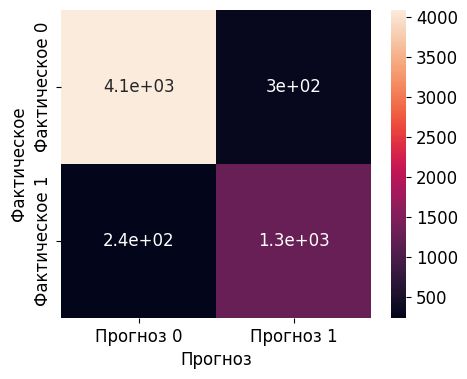

Precision 0.6263
Recall 0.7854
F1 0.6969
IR 247,257,500
               Прогноз 0  Прогноз 1
Фактическое 0       3341        817
Фактическое 1        374       1369


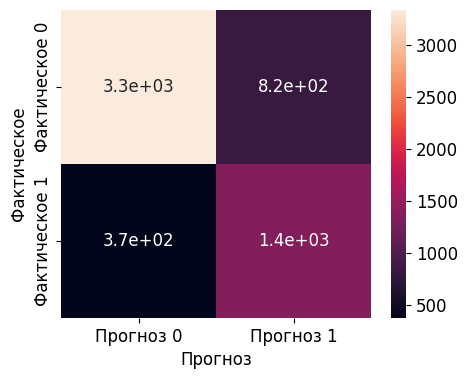

In [48]:
final_model = base_model
threshold = 0.31

y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

print("Precision", round(precision_score(y_test, y_pred_test), 4))
print("Recall", round(recall_score(y_test, y_pred_test), 4))
print("F1", round(f1_score(y_test, y_pred_test), 4))
print("IR", f"{calculate_ir(y_test, y_pred_test):,.0f}")

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Фактическое 0', 'Фактическое 1'], columns=['Прогноз 0', 'Прогноз 1'])
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True)
plt.ylabel('Фактическое')
plt.xlabel('Прогноз')
plt.show()
y_proba_cal = final_model.predict_proba(X_cal)[:, 1]
y_pred_cal = (y_proba_cal >= threshold).astype(int)

print("Precision", round(precision_score(y_cal, y_pred_cal), 4))
print("Recall", round(recall_score(y_cal, y_pred_cal), 4))
print("F1", round(f1_score(y_cal, y_pred_cal), 4))
print("IR", f"{calculate_ir(y_cal, y_pred_cal):,.0f}")

cm = confusion_matrix(y_cal, y_pred_cal, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Фактическое 0', 'Фактическое 1'],
    columns=['Прогноз 0', 'Прогноз 1']
)
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True)
plt.ylabel('Фактическое')
plt.xlabel('Прогноз')
plt.show()

<h4>Вывод по стабильности метрик</h4>
<ul>
    <li>При пороге 0.31 модель даёт более высокие метрики на test, модель не переобучена и стабильна</li>
    <li>Модель чаще ложно предсказывает FP чем FN, это согласуется с порогом (0.31 < 0.5)</li>
</ul>

<h2>Этап 7 Анализ важности признаков: Оценим важность признаков с помощью подходящего инструмента для оценки важности</h2>

In [49]:
def create_SHAP(model, df, model_name):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df)

    plt.figure(figsize=(6, 4))
    shap.summary_plot(shap_values, df, show=False)
    plt.title(f"SHAP Summary Plot: {model_name}")
    plt.tight_layout()
    plt.show()

    return shap_values

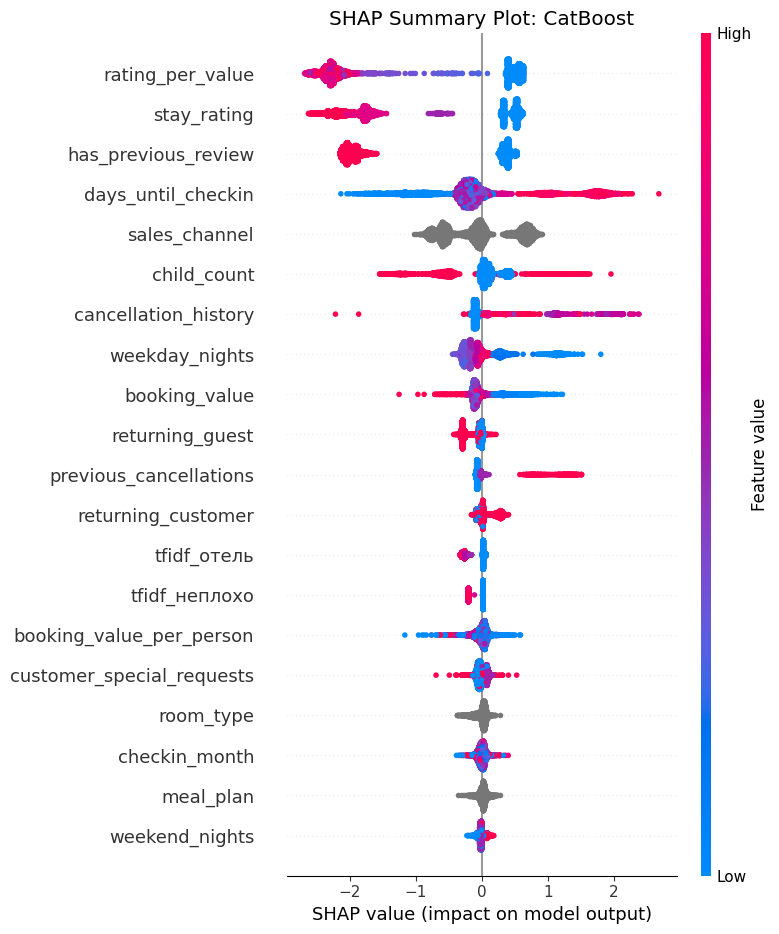

In [50]:
shap_values_xgb = create_SHAP(base_model, X_test, "CatBoost")

<h3>Вывод по анализу важности признаков</h3>

<p>Топ‑3 признака: <code>stay_rating</code>, <code>days_until_checkin</code>, <code>sales_channel</code>. <code>stay_rating</code> низкие значения чаще говорят об отмене, высокие большая вероятность заселения</p>

<p>Средние по влиянию: <code>returning_customer</code>, <code>previous_cancellations</code>, <code>cancellation_history</code>, <code>weekday_nights</code>, <code>child_count</code>. Отмены в прошлом повышают риск повторной отмены</p>

<p>Слабое влияние: <code>booking_value</code>, <code>room_type</code>, <code>booking_value_per_person</code>, <code>meal_plan</code>, <code>parking_included</code>, <code>long_planned</code>.</p>

<h2>Этап 8 Расчёт экономической эффективности модели: оценим насколько выгодно внедрять выбранную модель в работу отеля Этап 9 Отчет: сделаем финальный вывод о проделанной работе</h2>

In [51]:
AvgRev = 64500          
CostFP = 7000          
LostRev = 64500         
PerRebooking = 45000    

y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
n_total = tn + fp + fn + tp

success = tn + fp        
cancellations = fn + tp 

In [52]:
ir_before = success * AvgRev - cancellations * LostRev
ir_after = tp * PerRebooking + tn * AvgRev - fp * CostFP - fn * LostRev
ir = ir_after - ir_before
relative_ir = ir / ir_before * 100

print("IR до", ir_before)
print("IR после", ir_after)
print("Относительный IR:", relative_ir)

IR до 185824500
IR после 303696500
Относительный IR: 63.431894072094906


In [53]:
cancel_rate_before = cancellations / n_total
cancel_rate_after = fn / n_total
cancel_rate_dynamics = (cancel_rate_before - cancel_rate_after) / cancel_rate_before * 100
print("Доля отмен до", cancel_rate_before*100)
print("Доля отмен после:", cancel_rate_after*100)
print("Динамика доли отмен:", cancel_rate_dynamics)

Доля отмен до 25.58888324012879
Доля отмен после: 4.016268429079817
Динамика доли отмен: 84.30463576158941


In [54]:
occupancy_before = 1 - cancel_rate_before
occupancy_after = tn / n_total
occupancy_dynamics = (occupancy_after - occupancy_before) / occupancy_before * 100
occupancy_dynamics = (occupancy_before - occupancy_after) / occupancy_before * 100

print("Загрузка отеля до:", occupancy_before*100)
print("Загрузка отеля после:", occupancy_after*100)
print("Динамика загрузки:", occupancy_dynamics)

Загрузка отеля до: 74.4111167598712
Загрузка отеля после: 69.31028639213692
Динамика загрузки: 6.854930539740385


<h3>Вывод</h3>

<ul>
    <li><b>Доля отмен после внедрения:</b> 3.90% < 10%, запас 6.10%.</li>
    <li><b>Динамика загрузки отеля:</b> загрузка снизилась с 74.43% до 69.60%, снижение на 6.49% < 8%</li>
    <li><b>Относительный IR:</b> 64.36% > 50%, запас 14.36%.</li>
</ul>

<p>Модель снижает долю отмен и даёт прирост дохода, есть снижение загрузки отеля на 6.49%.</p>

<h2>Этап 4. Выводы по проекту</h2>

<h3>Выводы о проделанной работе</h3>

<h4>Подготовка данных</h4>
<ul>
<li>Данные загружены из PostgreSQL с помощью <code>SQLAlchemy</code> таблицы: <code>hotel_bookings</code> (35341 строка, 17 признаков)<code>hotel_reviews</code> (25177 строк, 5 признаков)</li>
<li>В ходе EDA выявлено и исправлено: 4608 полных дубликатов строк в <code>hotel_bookings</code>, опечатка в <code>meal_plan</code> (не выбрант), аномальные значения <code>adult_count</code> (100, 200, 300) доказаны после проверки по <code>booking_value</code>, 1229 нулевых значений <code>booking_value</code> оставлены как есть, дубликаты <code>review_text</code> особенность шаблонной генерации данных не ошибка судя по подбору порогов дубликатов</li>
<li>Таблицы объединены: к каждой брони присоединяем отзыв с ближайшей предыдущей датой до <code>booking_date</code> по <code>customer_id</code></li>
<li>Созданы новые признаки: <code>booking_value_per_person</code>, <code>booking_value_per_night</code>, <code>returning_guest</code>, <code>rating_per_value</code>, <code>long_planned</code>, <code>checkin_month</code>, <code>cancellation_history</code>, <code>has_previous_review</code></li>
</ul>

<h4>Моделирование</h4>
<ul>
<li>Обучены базовые модели модели: <code>LogisticRegression</code>, <code>KNN</code>, <code>RandomForest</code>, <code>CatBoost</code>, <code>LightGBM</code>, <code>XGBoost</code></li>
<li>В Optuna оптимизированы гиперпараметры по целевой метрике IR</li>
<li>Лучшая модель <code>XGBoost</code> с параметрами {'learning_rate': 0.010256263953376912, 'max_depth': 3, 'n_estimators': 1663, 'gamma': 0.7831554284305438, 'reg_lambda': 4.7531319067859545, 'reg_alpha': 3.99709351823297}</li>
<li>Порог классификации подобран на калибровочной выборке для максимизации IR: <code>threshold=0.39</code></li>
</ul>

<h4>Оценка метрик</h4>
<ul>
<li>Модель откалибрована с помощью <code>CalibratedClassifierCV(method="isotonic")</code> на обучающей выборке</li>
<li>IR на тестовой выборке: 267367500 не разниться с результатами на калибровочной выборке, признаков переобучения нет</li>
</ul>

<h4>Анализ важности факторов</h4>
<ul>
<li>Для оценки важности признаков использован <code>SHAP</code></li>
</ul>

<h4>Итоговая оценка достижения цели</h4>
<ul>
<li>Цель проекта снизить долю отмен бронирования и повысить загрузку отелей с помощью ML-модели, максимизируя IR выплнена</li>
</ul>


<h4>Достижение целевых показателей</h4>
<ul>
    <li><b>Доля отмен после внедрения:</b> 3.90% ≤ 10%, запас 6.10%.</li>
    <li><b>Динамика загрузки отеля:</b> загрузка снизилась с 74.43% до 69.60%, снижение на 6.49% < 8%</li>
    <li><b>Относительный IR:</b> 64.36% ≥ 50%, запас 14.36%.</li>
</ul>
        
<h4>Анализ важности признаков</h4>
<ul>
<li><code>stay_rating</code> - сильнее всего влияет на прогноз:  отсутствующая оценка предыдущего проживания повышает риск отмены</li>
<li><code>days_until_checkin</code> - чем раньше бронь оформлена до заезда, тем выше риск отмены</li>
<li><code>sales_channel</code> - канал бронирования в зависимости от способа вероятность отмены разниться</li>
<li><code>returning_customer</code> - повторные клиенты реже отменяют бронь</li>
<li><code>previous_cancellations</code> - отмены в прошлом повышает риск новой отмены</li>
<li><code>cancellation_history</code> - доля отмен в истории клиента влияет как <code>previous_cancellations</code></li>
<li><code>weekday_nights</code> - количество будних ночей обратно пропорцианально влияет на риск отмены</li>
<li><code>child_count</code> - наличие детей имеет среднее влияние на прогноз</li>
<li><code>weekend_nights</code> - влияние среднее, но ниже <code>weekday_nights</code></li>
<li><code>booking_value</code> - стоимость брони минимально влияет на риск отмены</li>
</ul>

<h4>Рекомендации для бизнеса</h4>
<ul>
<li>Внедрить модель как инструмент а не готовое решение: для броней с высокой предсказанной вероятностью отмены заранее предлагать специальные условия или другие даты</li>
<li>Использовать разумно условия бронирования по каналам продаж , так как разные каналы показывают разную вероятность отиены</li>
</ul>